# Transformaciones Geométricas en Forma Matricial

**BME423 - Procesamiento de Imágenes Médicas**

En este notebook implementaremos las transformaciones geométricas vistas en clase usando matrices homogéneas 4x4. Esto incluye:

1. **Traslación** - Mover una imagen en el espacio
2. **Escalamiento** - Cambiar el tamaño de una imagen
3. **Rotación** - Rotar una imagen alrededor de diferentes ejes
4. **Transformaciones combinadas** - Aplicar múltiples transformaciones
5. **Aplicación a imágenes** - Implementar el algoritmo de transformación con interpolación

In [29]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import map_coordinates
import math

# Configuración para visualización
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 10

print("Bibliotecas importadas correctamente")

Bibliotecas importadas correctamente


## 1. Matrices de Transformación Básicas

### Coordenadas Homogéneas

Las transformaciones geométricas se representan usando coordenadas homogéneas con matrices 4x4:

$$\begin{bmatrix} x' \\ y' \\ z' \\ 1 \end{bmatrix} = M \begin{bmatrix} x \\ y \\ z \\ 1 \end{bmatrix}$$

donde $M$ es la matriz de transformación de 4x4.

In [30]:
def translation_matrix(tx, ty, tz=0):
    """
    Crea una matriz de traslación 4x4
    
    Parámetros:
    tx, ty, tz: componentes de traslación en x, y, z
    
    Matriz resultante:
    [1  0  0  tx]
    [0  1  0  ty]
    [0  0  1  tz]
    [0  0  0   1]
    """
    T = np.eye(4)
    T[0, 3] = tx
    T[1, 3] = ty
    T[2, 3] = tz
    return T

# Ejemplo de uso
T_example = translation_matrix(10, 5, 0)
print("Matriz de traslación (tx=10, ty=5):")
print(T_example)

# Aplicar transformación a un punto
point = np.array([1, 1, 0, 1])  # punto homogéneo (x=1, y=1, z=0)
transformed_point = T_example @ point
print(f"\nPunto original: ({point[0]}, {point[1]})")
print(f"Punto transformado: ({transformed_point[0]}, {transformed_point[1]})")

Matriz de traslación (tx=10, ty=5):
[[ 1.  0.  0. 10.]
 [ 0.  1.  0.  5.]
 [ 0.  0.  1.  0.]
 [ 0.  0.  0.  1.]]

Punto original: (1, 1)
Punto transformado: (11.0, 6.0)


In [31]:
def scaling_matrix(sx, sy, sz=1):
    """
    Crea una matriz de escalamiento 4x4
    
    Parámetros:
    sx, sy, sz: factores de escala en x, y, z
    
    Matriz resultante:
    [sx  0  0  0]
    [0  sy  0  0]
    [0   0 sz  0]
    [0   0  0  1]
    """
    S = np.eye(4)
    S[0, 0] = sx
    S[1, 1] = sy
    S[2, 2] = sz
    return S

# Ejemplo de uso
S_example = scaling_matrix(2, 0.5, 1)
print("Matriz de escalamiento (sx=2, sy=0.5):")
print(S_example)

# Aplicar transformación a un punto
point = np.array([4, 6, 0, 1])
transformed_point = S_example @ point
print(f"\nPunto original: ({point[0]}, {point[1]})")
print(f"Punto transformado: ({transformed_point[0]}, {transformed_point[1]})")

Matriz de escalamiento (sx=2, sy=0.5):
[[2.  0.  0.  0. ]
 [0.  0.5 0.  0. ]
 [0.  0.  1.  0. ]
 [0.  0.  0.  1. ]]

Punto original: (4, 6)
Punto transformado: (8.0, 3.0)


In [32]:
def rotation_matrix_x(alpha):
    """
    Crea una matriz de rotación alrededor del eje X
    
    Parámetro:
    alpha: ángulo de rotación en radianes
    
    Matriz resultante:
    [1    0         0      0]
    [0  cos(α)  -sin(α)   0]
    [0  sin(α)   cos(α)   0]
    [0    0         0      1]
    """
    Rx = np.eye(4)
    cos_a = np.cos(alpha)
    sin_a = np.sin(alpha)
    
    Rx[1, 1] = cos_a
    Rx[1, 2] = -sin_a
    Rx[2, 1] = sin_a
    Rx[2, 2] = cos_a
    
    return Rx

def rotation_matrix_y(beta):
    """
    Crea una matriz de rotación alrededor del eje Y
    
    Parámetro:
    beta: ángulo de rotación en radianes
    
    Matriz resultante:
    [cos(β)   0  sin(β)  0]
    [  0      1    0     0]
    [-sin(β)  0  cos(β)  0]
    [  0      0    0     1]
    """
    Ry = np.eye(4)
    cos_b = np.cos(beta)
    sin_b = np.sin(beta)
    
    Ry[0, 0] = cos_b
    Ry[0, 2] = sin_b
    Ry[2, 0] = -sin_b
    Ry[2, 2] = cos_b
    
    return Ry

def rotation_matrix_z(gamma):
    """
    Crea una matriz de rotación alrededor del eje Z
    
    Parámetro:
    gamma: ángulo de rotación en radianes
    
    Matriz resultante:
    [cos(γ)  -sin(γ)  0  0]
    [sin(γ)   cos(γ)  0  0]
    [  0        0     1  0]
    [  0        0     0  1]
    """
    Rz = np.eye(4)
    cos_g = np.cos(gamma)
    sin_g = np.sin(gamma)
    
    Rz[0, 0] = cos_g
    Rz[0, 1] = -sin_g
    Rz[1, 0] = sin_g
    Rz[1, 1] = cos_g
    
    return Rz

# Ejemplos de uso
angle_45 = np.pi / 4  # 45 grados en radianes

print("Matriz de rotación Z (45°):")
Rz_45 = rotation_matrix_z(angle_45)
print(Rz_45)

# Aplicar rotación a un punto
point = np.array([1, 0, 0, 1])  # punto en (1,0,0)
rotated_point = Rz_45 @ point
print(f"\nPunto original: ({point[0]:.1f}, {point[1]:.1f})")
print(f"Punto rotado 45°: ({rotated_point[0]:.3f}, {rotated_point[1]:.3f})")

Matriz de rotación Z (45°):
[[ 0.70710678 -0.70710678  0.          0.        ]
 [ 0.70710678  0.70710678  0.          0.        ]
 [ 0.          0.          1.          0.        ]
 [ 0.          0.          0.          1.        ]]

Punto original: (1.0, 0.0)
Punto rotado 45°: (0.707, 0.707)


## 2. Transformaciones Combinadas

Las transformaciones se pueden combinar multiplicando matrices. El orden de multiplicación es importante:

**Transformación completa = T · R · S** (aplicada de derecha a izquierda)

1. Primero se aplica escalamiento (S)
2. Luego rotación (R) 
3. Finalmente traslación (T)

In [33]:
def combined_transformation(translation=(0,0,0), rotation_angles=(0,0,0), scaling=(1,1,1)):
    """
    Crea una matriz de transformación combinada
    
    Parámetros:
    translation: tupla (tx, ty, tz) para traslación
    rotation_angles: tupla (alpha, beta, gamma) en radianes para rotaciones X, Y, Z
    scaling: tupla (sx, sy, sz) para escalamiento
    
    Retorna:
    Matriz 4x4 de transformación combinada = T * Rz * Ry * Rx * S
    """
    # Crear matrices individuales
    T = translation_matrix(*translation)
    Rx = rotation_matrix_x(rotation_angles[0])
    Ry = rotation_matrix_y(rotation_angles[1]) 
    Rz = rotation_matrix_z(rotation_angles[2])
    S = scaling_matrix(*scaling)
    
    # Combinar transformaciones (orden: T * Rz * Ry * Rx * S)
    combined = T @ Rz @ Ry @ Rx @ S
    
    return combined, {'T': T, 'Rx': Rx, 'Ry': Ry, 'Rz': Rz, 'S': S}

# Ejemplo: rotar 30°, escalar 2x en X, trasladar (5, 3)
angle_30 = np.pi / 6
combined_matrix, individual_matrices = combined_transformation(
    translation=(5, 3, 0),
    rotation_angles=(0, 0, angle_30),  # 30° en Z
    scaling=(2, 1, 1)  # 2x en X
)

print("Matriz de transformación combinada:")
print(combined_matrix)

# Aplicar a varios puntos
points = np.array([
    [0, 0, 0, 1],  # origen
    [1, 0, 0, 1],  # punto en X
    [0, 1, 0, 1],  # punto en Y
    [1, 1, 0, 1]   # esquina
]).T

transformed_points = combined_matrix @ points

print("\nTransformación de puntos:")
for i, (orig, trans) in enumerate(zip(points.T, transformed_points.T)):
    print(f"Punto {i+1}: ({orig[0]:.1f}, {orig[1]:.1f}) → ({trans[0]:.2f}, {trans[1]:.2f})")

Matriz de transformación combinada:
[[ 1.73205081 -0.5         0.          5.        ]
 [ 1.          0.8660254   0.          3.        ]
 [ 0.          0.          1.          0.        ]
 [ 0.          0.          0.          1.        ]]

Transformación de puntos:
Punto 1: (0.0, 0.0) → (5.00, 3.00)
Punto 2: (1.0, 0.0) → (6.73, 4.00)
Punto 3: (0.0, 1.0) → (4.50, 3.87)
Punto 4: (1.0, 1.0) → (6.23, 4.87)


## 3. Aplicación a Imágenes

Para transformar imágenes, usamos el algoritmo visto en clase:

1. **Para cada pixel (i,j) en la imagen destino J:**
   - Calcular las coordenadas correspondientes (i₀,j₀) en la imagen origen I
   - Usar la transformación inversa: `[i₀, j₀, 0, 1]ᵀ = M⁻¹ [i, j, 0, 1]ᵀ`

2. **Interpolar el valor:**
   - Si (i₀,j₀) cae exactamente en un pixel: `J(i,j) = I(i₀,j₀)`
   - Si no: usar interpolación (vecino más cercano o bilineal)

In [34]:
def transform_image(image, transformation_matrix, output_shape=None, interpolation='bilinear'):
    """
    Aplica una transformación geométrica a una imagen
    
    Parámetros:
    image: imagen de entrada (numpy array 2D)
    transformation_matrix: matriz de transformación 4x4
    output_shape: forma de la imagen de salida (height, width). Si None, usa la forma original
    interpolation: tipo de interpolación ('nearest' o 'bilinear')
    
    Retorna:
    Imagen transformada
    """
    if output_shape is None:
        output_shape = image.shape
    
    height, width = output_shape
    
    # Crear imagen de salida
    transformed_image = np.zeros(output_shape)
    
    # Matriz de transformación inversa
    inv_matrix = np.linalg.inv(transformation_matrix)
    
    # Para cada pixel en la imagen de salida
    for i in range(height):
        for j in range(width):
            # Coordenadas homogéneas del pixel de salida
            output_coords = np.array([j, i, 0, 1])  # (x, y, z, 1)
            
            # Aplicar transformación inversa para encontrar coordenadas en imagen original
            input_coords = inv_matrix @ output_coords
            
            # Extraer coordenadas x, y
            x0, y0 = input_coords[0], input_coords[1]
            
            # Verificar si las coordenadas están dentro de la imagen original
            if 0 <= x0 < image.shape[1] and 0 <= y0 < image.shape[0]:
                if interpolation == 'nearest':
                    # Interpolación por vecino más cercano
                    x_near = int(round(x0))
                    y_near = int(round(y0))
                    if 0 <= x_near < image.shape[1] and 0 <= y_near < image.shape[0]:
                        transformed_image[i, j] = image[y_near, x_near]
                
                elif interpolation == 'bilinear':
                    # Interpolación bilineal
                    x_floor, y_floor = int(np.floor(x0)), int(np.floor(y0))
                    x_ceil, y_ceil = x_floor + 1, y_floor + 1
                    
                    # Verificar límites
                    if x_ceil < image.shape[1] and y_ceil < image.shape[0]:
                        # Pesos para interpolación
                        wx = x0 - x_floor
                        wy = y0 - y_floor
                        
                        # Interpolación bilineal
                        I1 = image[y_floor, x_floor]
                        I2 = image[y_floor, x_ceil]
                        I3 = image[y_ceil, x_floor]
                        I4 = image[y_ceil, x_ceil]
                        
                        transformed_image[i, j] = (
                            (1-wx)*(1-wy)*I1 + wx*(1-wy)*I2 + 
                            (1-wx)*wy*I3 + wx*wy*I4
                        )
    
    return transformed_image

# Crear una imagen de prueba simple
def create_test_image():
    """Crea una imagen de prueba con un patrón geométrico"""
    img = np.zeros((100, 100))
    
    # Cuadrado central
    img[30:70, 30:70] = 1.0
    
    # Líneas diagonales
    for i in range(100):
        if i < 100:
            img[i, i] = 0.5
        if i < 100:
            img[i, 99-i] = 0.5
    
    # Círculo
    center_x, center_y = 50, 50
    radius = 15
    y, x = np.ogrid[:100, :100]
    mask = (x - center_x)**2 + (y - center_y)**2 <= radius**2
    img[mask] = 0.7
    
    return img

# Crear imagen de prueba
test_image = create_test_image()

print(f"Imagen de prueba creada: {test_image.shape}")
print(f"Valores únicos: {np.unique(test_image)}")

Imagen de prueba creada: (100, 100)
Valores únicos: [0.  0.5 0.7 1. ]


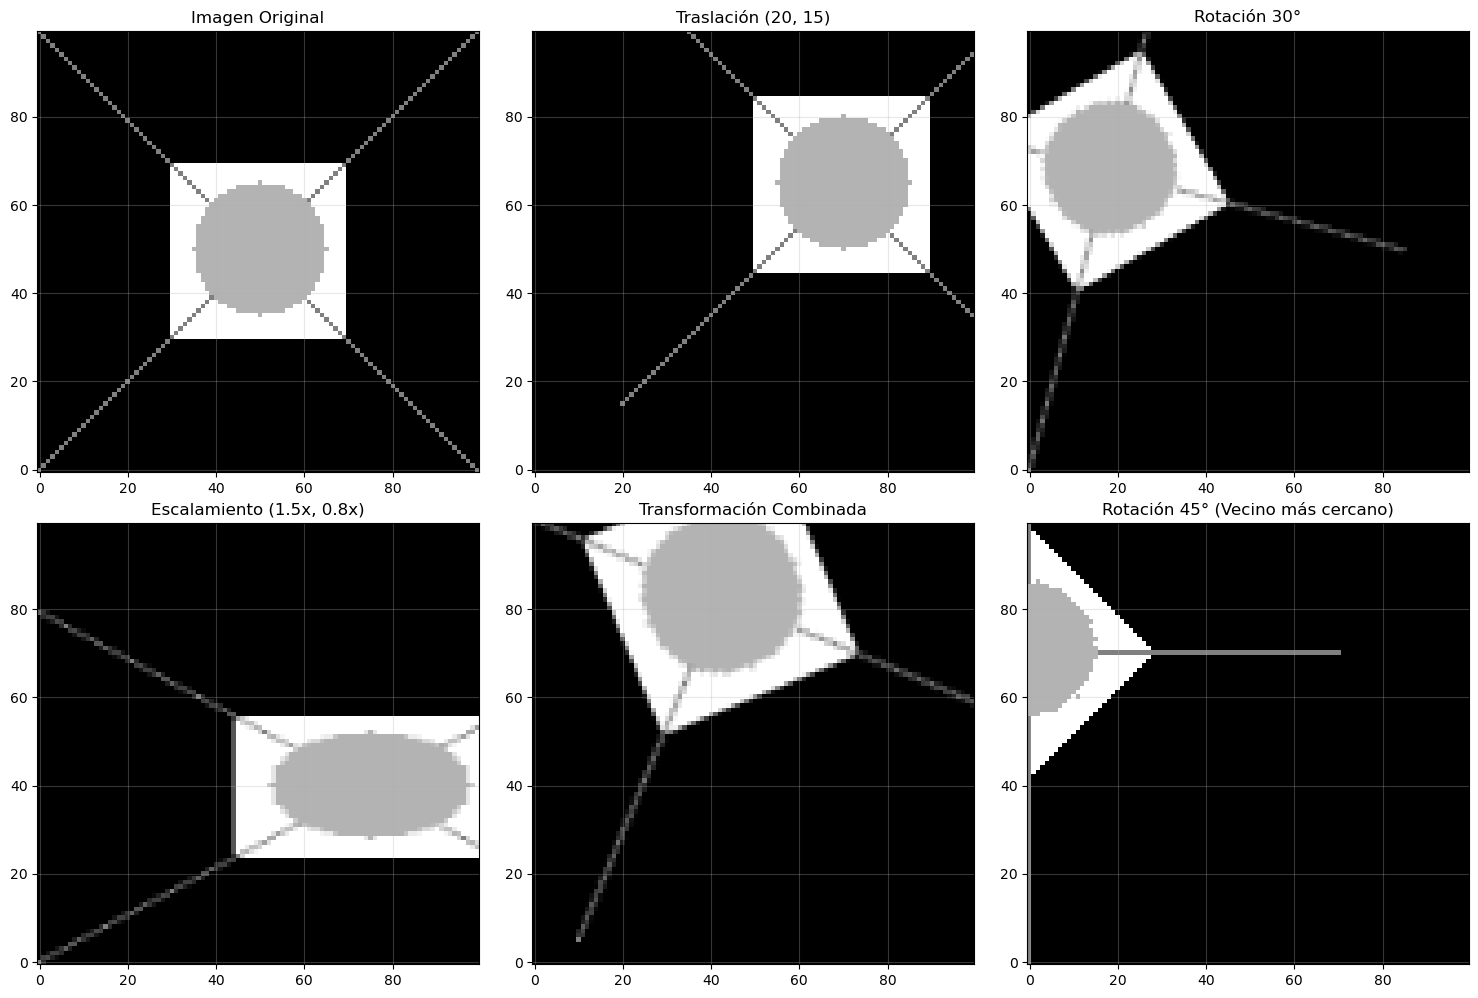

Transformaciones aplicadas:
1. Traslación: Mueve la imagen 20 pixels en X y 15 en Y
2. Rotación: Rota 30° alrededor del origen
3. Escalamiento: Estira 1.5x en X y comprime 0.8x en Y
4. Combinada: Traslación + Rotación + Escalamiento
5. Interpolación: Comparación entre bilineal y vecino más cercano


In [35]:
# Visualizar imagen original y aplicar diferentes transformaciones
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Imagen original
axes[0, 0].imshow(test_image, cmap='gray', origin='lower')
axes[0, 0].set_title('Imagen Original')
axes[0, 0].grid(True, alpha=0.3)

# 1. Solo traslación
T_trans = translation_matrix(20, 15)
img_translated = transform_image(test_image, T_trans, interpolation='bilinear')
axes[0, 1].imshow(img_translated, cmap='gray', origin='lower')
axes[0, 1].set_title('Traslación (20, 15)')
axes[0, 1].grid(True, alpha=0.3)

# 2. Solo rotación
angle_30 = np.pi / 6
T_rot = rotation_matrix_z(angle_30)
img_rotated = transform_image(test_image, T_rot, interpolation='bilinear')
axes[0, 2].imshow(img_rotated, cmap='gray', origin='lower')
axes[0, 2].set_title('Rotación 30°')
axes[0, 2].grid(True, alpha=0.3)

# 3. Solo escalamiento
T_scale = scaling_matrix(1.5, 0.8)
img_scaled = transform_image(test_image, T_scale, interpolation='bilinear')
axes[1, 0].imshow(img_scaled, cmap='gray', origin='lower')
axes[1, 0].set_title('Escalamiento (1.5x, 0.8x)')
axes[1, 0].grid(True, alpha=0.3)

# 4. Transformación combinada
T_combined, _ = combined_transformation(
    translation=(10, 5, 0),
    rotation_angles=(0, 0, np.pi/8),  # 22.5°
    scaling=(1.2, 1.2, 1)
)
img_combined = transform_image(test_image, T_combined, interpolation='bilinear')
axes[1, 1].imshow(img_combined, cmap='gray', origin='lower')
axes[1, 1].set_title('Transformación Combinada')
axes[1, 1].grid(True, alpha=0.3)

# 5. Comparación de interpolaciones
T_rot_45 = rotation_matrix_z(np.pi/4)
img_nearest = transform_image(test_image, T_rot_45, interpolation='nearest')
axes[1, 2].imshow(img_nearest, cmap='gray', origin='lower')
axes[1, 2].set_title('Rotación 45° (Vecino más cercano)')
axes[1, 2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Transformaciones aplicadas:")
print("1. Traslación: Mueve la imagen 20 pixels en X y 15 en Y")
print("2. Rotación: Rota 30° alrededor del origen")
print("3. Escalamiento: Estira 1.5x en X y comprime 0.8x en Y")
print("4. Combinada: Traslación + Rotación + Escalamiento")
print("5. Interpolación: Comparación entre bilineal y vecino más cercano")

## 4. Simulación de Registro de Imágenes

El registro de imágenes busca encontrar la transformación óptima que alinea dos imágenes. Aquí simularemos el proceso:

1. **Imagen referencia** (fija)
2. **Imagen flotante** (a transformar) 
3. **Función de costo** para medir la calidad del alineamiento
4. **Optimización** para encontrar los mejores parámetros

In [36]:
def cost_function_ssd(img1, img2):
    """
    Suma de Diferencias al Cuadrado (SSD)
    SSD(f,g) = Σ(f_mn - g_mn)²
    """
    return np.sum((img1 - img2) ** 2)

def cost_function_sad(img1, img2):
    """
    Suma de Diferencias Absolutas (SAD)  
    SAD(f,g) = Σ|f_mn - g_mn|
    """
    return np.sum(np.abs(img1 - img2))

def cost_function_ncc(img1, img2):
    """
    Correlación Cruzada Normalizada (NCC)
    CC(f,g) = Σf_mn*g_mn / sqrt(Σf_mn² * Σg_mn²)
    """
    # Normalizar intensidades
    img1_norm = img1 - np.mean(img1)
    img2_norm = img2 - np.mean(img2)
    
    numerator = np.sum(img1_norm * img2_norm)
    denominator = np.sqrt(np.sum(img1_norm**2) * np.sum(img2_norm**2))
    
    if denominator == 0:
        return 0
    
    return numerator / denominator

def evaluate_registration(reference_img, floating_img, transformation_params):
    """
    Evalúa la calidad del registro para parámetros dados
    
    Parámetros:
    reference_img: imagen de referencia
    floating_img: imagen flotante a transformar
    transformation_params: [tx, ty, rotation_angle, sx, sy]
    
    Retorna:
    Diccionario con costos y imagen transformada
    """
    tx, ty, angle, sx, sy = transformation_params
    
    # Crear matriz de transformación
    T_matrix, _ = combined_transformation(
        translation=(tx, ty, 0),
        rotation_angles=(0, 0, angle),
        scaling=(sx, sy, 1)
    )
    
    # Transformar imagen flotante
    transformed_img = transform_image(floating_img, T_matrix, 
                                    output_shape=reference_img.shape,
                                    interpolation='bilinear')
    
    # Calcular costos
    ssd = cost_function_ssd(reference_img, transformed_img)
    sad = cost_function_sad(reference_img, transformed_img)
    ncc = cost_function_ncc(reference_img, transformed_img)
    
    return {
        'ssd': ssd,
        'sad': sad, 
        'ncc': ncc,
        'transformed_image': transformed_img,
        'transformation_matrix': T_matrix
    }

# Crear imágenes para registro
reference_image = create_test_image()

# Crear imagen flotante con transformación conocida
true_params = [15, 10, np.pi/6, 1.1, 0.9]  # traslación, rotación, escala
T_true, _ = combined_transformation(
    translation=(true_params[0], true_params[1], 0),
    rotation_angles=(0, 0, true_params[2]),
    scaling=(true_params[3], true_params[4], 1)
)

floating_image = transform_image(reference_image, T_true, interpolation='bilinear')

print("Parámetros de transformación reales:")
print(f"Traslación: ({true_params[0]}, {true_params[1]})")
print(f"Rotación: {true_params[2]*180/np.pi:.1f}°")
print(f"Escalamiento: ({true_params[3]}, {true_params[4]})")

Parámetros de transformación reales:
Traslación: (15, 10)
Rotación: 30.0°
Escalamiento: (1.1, 0.9)


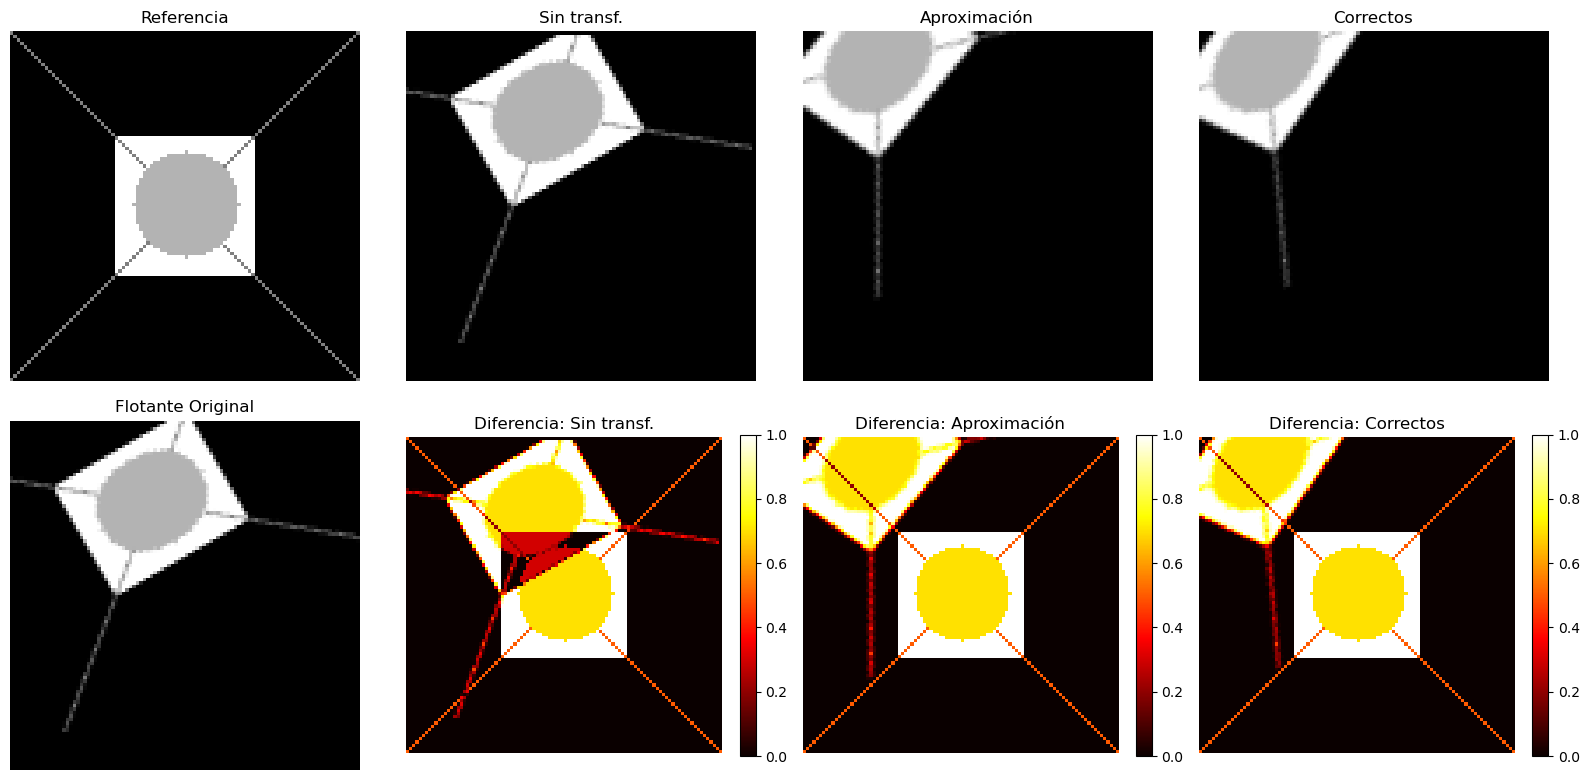

\nMétricas de costo para diferentes parámetros:
Parámetros      SSD        SAD        NCC       
------------------------------------------------------------
Sin transf.     1811.95    2196.58    0.099     
Aproximación    2026.93    2378.82    -0.151    
Correctos       1949.95    2290.53    -0.142    
Incorrectos     1732.47    2043.93    -0.118    
\nObservaciones:
- SSD y SAD: valores menores indican mejor alineación
- NCC: valores cercanos a 1 indican mejor alineación
- Los parámetros correctos deberían dar el mejor costo


In [37]:
# Probar diferentes parámetros para simular optimización
test_params = [
    [0, 0, 0, 1, 1],           # Sin transformación
    [10, 8, np.pi/8, 1.05, 0.95],  # Aproximación cercana
    [15, 10, np.pi/6, 1.1, 0.9],   # Parámetros correctos
    [20, 15, np.pi/4, 1.2, 0.8],   # Parámetros incorrectos
]

param_names = ['Sin transf.', 'Aproximación', 'Correctos', 'Incorrectos']

# Evaluar cada conjunto de parámetros
results = []
for params in test_params:
    result = evaluate_registration(reference_image, floating_image, params)
    results.append(result)

# Visualizar resultados
fig, axes = plt.subplots(2, 4, figsize=(16, 8))

# Fila superior: imágenes
axes[0, 0].imshow(reference_image, cmap='gray', origin='lower')
axes[0, 0].set_title('Referencia')
axes[0, 0].axis('off')

for i, (result, name) in enumerate(zip(results, param_names)):
    if i < 3:
        axes[0, i+1].imshow(result['transformed_image'], cmap='gray', origin='lower')
        axes[0, i+1].set_title(f'{name}')
        axes[0, i+1].axis('off')

# Fila inferior: diferencias
axes[1, 0].imshow(floating_image, cmap='gray', origin='lower')
axes[1, 0].set_title('Flotante Original')
axes[1, 0].axis('off')

for i, (result, name) in enumerate(zip(results, param_names)):
    if i < 3:
        difference = np.abs(reference_image - result['transformed_image'])
        im = axes[1, i+1].imshow(difference, cmap='hot', origin='lower')
        axes[1, i+1].set_title(f'Diferencia: {name}')
        axes[1, i+1].axis('off')
        plt.colorbar(im, ax=axes[1, i+1], fraction=0.046)

plt.tight_layout()
plt.show()

# Mostrar métricas de costo
print("\\nMétricas de costo para diferentes parámetros:")
print("=" * 60)
print(f"{'Parámetros':<15} {'SSD':<10} {'SAD':<10} {'NCC':<10}")
print("-" * 60)

for i, (params, result, name) in enumerate(zip(test_params, results, param_names)):
    print(f"{name:<15} {result['ssd']:<10.2f} {result['sad']:<10.2f} {result['ncc']:<10.3f}")

print("\\nObservaciones:")
print("- SSD y SAD: valores menores indican mejor alineación")
print("- NCC: valores cercanos a 1 indican mejor alineación") 
print("- Los parámetros correctos deberían dar el mejor costo")

## 5. Resumen y Conclusiones

### Matrices de Transformación Implementadas

✅ **Traslación**: `T = [[1,0,0,tx], [0,1,0,ty], [0,0,1,tz], [0,0,0,1]]`

✅ **Escalamiento**: `S = [[sx,0,0,0], [0,sy,0,0], [0,0,sz,0], [0,0,0,1]]`

✅ **Rotación alrededor de X**: `Rx = [[1,0,0,0], [0,cos(α),-sin(α),0], [0,sin(α),cos(α),0], [0,0,0,1]]`

✅ **Rotación alrededor de Y**: `Ry = [[cos(β),0,sin(β),0], [0,1,0,0], [-sin(β),0,cos(β),0], [0,0,0,1]]`

✅ **Rotación alrededor de Z**: `Rz = [[cos(γ),-sin(γ),0,0], [sin(γ),cos(γ),0,0], [0,0,1,0], [0,0,0,1]]`

### Algoritmo de Transformación de Imágenes

1. **Para cada pixel (i,j) en imagen destino J:**
   - Calcular coordenadas origen: `(i₀,j₀) = M⁻¹ × (i,j,0,1)`
   - Interpolar valor: `J(i,j) = Interpolación[I(i₀,j₀)]`

2. **Métodos de interpolación:**
   - **Vecino más cercano**: más rápido, puede generar artefactos
   - **Bilineal**: más suave, mejor calidad visual

### Funciones de Costo para Registro

- **SSD** (Suma de Diferencias al Cuadrado): sensible a diferencias de intensidad
- **SAD** (Suma de Diferencias Absolutas): más robusta a outliers  
- **NCC** (Correlación Cruzada Normalizada): invariante a cambios lineales de intensidad

### Aplicaciones en Imágenes Médicas

Las transformaciones geométricas son fundamentales para:
- **Registro multimodal** (CT-MRI, PET-CT)
- **Corrección de movimiento**
- **Seguimiento temporal**
- **Fusión de imágenes**

### Código Reutilizable

Todas las funciones implementadas pueden ser utilizadas directamente en proyectos de procesamiento de imágenes médicas.

=== EJEMPLO FINAL: TRANSFORMACIÓN MÉDICA ===



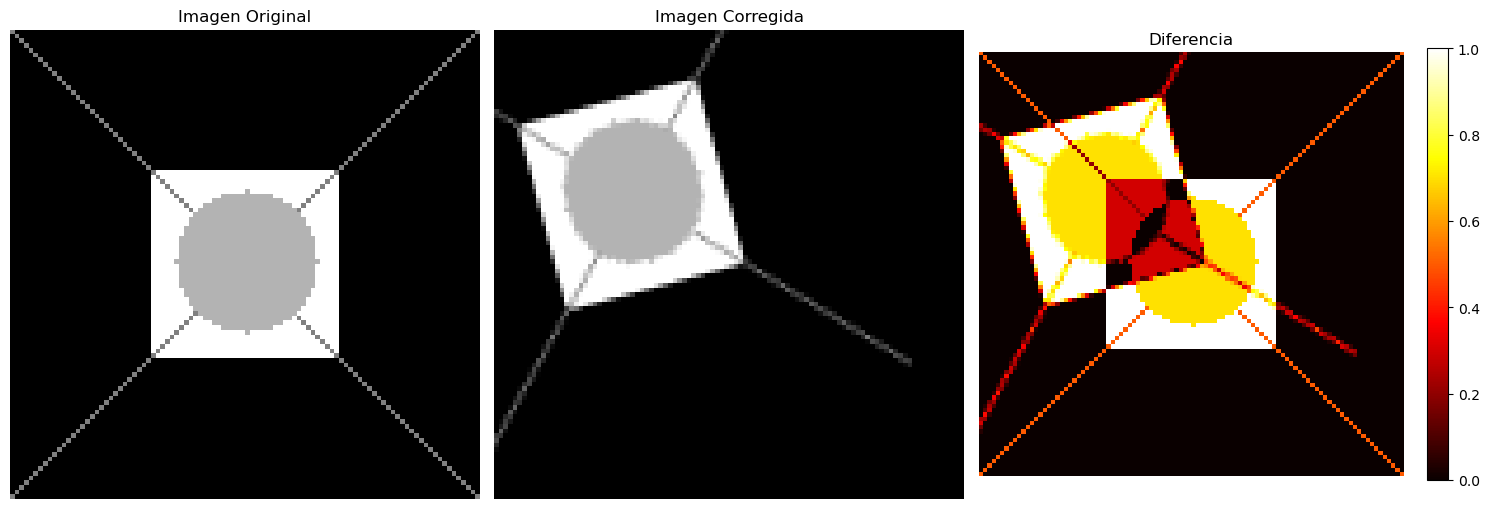

Matriz de transformación aplicada:
[[ 0.94660731 -0.26399543  0.         -5.        ]
 [ 0.25364266  0.98524434  0.          3.        ]
 [ 0.          0.          1.          0.        ]
 [ 0.          0.          0.          1.        ]]

¡Implementación completa de transformaciones geométricas!
Este código puede ser usado directamente en aplicaciones médicas.


In [38]:
# Ejemplo práctico: Función completa para transformar imágenes médicas
def transform_medical_image(image, tx=0, ty=0, tz=0, 
                          rotation_x=0, rotation_y=0, rotation_z=0,
                          scale_x=1, scale_y=1, scale_z=1,
                          interpolation='bilinear'):
    """
    Función completa para transformar imágenes médicas
    
    Parámetros:
    image: imagen de entrada (2D numpy array)
    tx, ty, tz: traslación en píxeles
    rotation_x, rotation_y, rotation_z: rotaciones en radianes
    scale_x, scale_y, scale_z: factores de escalamiento
    interpolation: 'nearest' o 'bilinear'
    
    Retorna:
    Imagen transformada y matriz de transformación utilizada
    """
    
    # Crear matriz de transformación combinada
    transformation_matrix, components = combined_transformation(
        translation=(tx, ty, tz),
        rotation_angles=(rotation_x, rotation_y, rotation_z),
        scaling=(scale_x, scale_y, scale_z)
    )
    
    # Aplicar transformación
    transformed_image = transform_image(image, transformation_matrix, 
                                      output_shape=image.shape,
                                      interpolation=interpolation)
    
    return transformed_image, transformation_matrix

# Ejemplo de uso final
print("=== EJEMPLO FINAL: TRANSFORMACIÓN MÉDICA ===")
print()

# Crear imagen simulada de scan médico
medical_image = create_test_image()

# Aplicar transformación compleja (como corrección de movimiento)
corrected_image, transform_matrix = transform_medical_image(
    medical_image,
    tx=-5,           # Corrección de traslación
    ty=3,
    rotation_z=np.pi/12,  # Corrección de rotación (15°)
    scale_x=0.98,    # Ligera corrección de escala
    scale_y=1.02,
    interpolation='bilinear'
)

# Mostrar resultado
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5))

ax1.imshow(medical_image, cmap='gray', origin='lower')
ax1.set_title('Imagen Original')
ax1.axis('off')

ax2.imshow(corrected_image, cmap='gray', origin='lower')
ax2.set_title('Imagen Corregida')
ax2.axis('off')

# Diferencia
difference = np.abs(medical_image - corrected_image)
im = ax3.imshow(difference, cmap='hot', origin='lower')
ax3.set_title('Diferencia')
ax3.axis('off')
plt.colorbar(im, ax=ax3, fraction=0.046)

plt.tight_layout()
plt.show()

print("Matriz de transformación aplicada:")
print(transform_matrix)
print()
print("¡Implementación completa de transformaciones geométricas!")
print("Este código puede ser usado directamente en aplicaciones médicas.")

## 6. Análisis de Volúmenes Médicos con Información Mutua

En esta sección aplicaremos transformaciones espaciales a volúmenes de CT de tórax y cuantificaremos la **información mutua** entre el volumen original y el transformado.

### Grilla de Transformaciones (9 dimensiones):
- **Traslación**: tx, ty, tz 
- **Escalamiento**: sx, sy, sz
- **Rotación**: rotx, roty, rotz

### Información Mutua:
$$MI(X,Y) = H(X) + H(Y) - H(X,Y)$$

donde H(X) es la entropía marginal y H(X,Y) es la entropía conjunta.

In [39]:
# Instalar paquetes necesarios
import subprocess
import sys

def install_package(package):
    try:
        subprocess.check_call([sys.executable, "-m", "pip", "install", package])
        print(f"✓ {package} instalado correctamente")
    except subprocess.CalledProcessError:
        print(f"✗ Error instalando {package}")

# Instalar librerías necesarias
print("Instalando librerías para imágenes médicas...")
install_package("pydicom")
install_package("nibabel")

# Importar librerías adicionales para manejo de volúmenes médicos
import os
import glob
from scipy.ndimage import zoom
from sklearn.metrics import mutual_info_score
from scipy.stats import entropy

# Intentar importar las librerías médicas
try:
    import pydicom
    print("✓ pydicom importado correctamente")
except ImportError:
    print("✗ Error importando pydicom")

try:
    import nibabel as nib
    print("✓ nibabel importado correctamente")
except ImportError:
    print("✗ Error importando nibabel")
    print("Continuaremos sin nibabel, usando solo pydicom")

print("Configuración completada.")

def load_ct_volume(folder_path):
    """
    Carga un volumen de CT desde archivos DICOM
    
    Parámetros:
    folder_path: ruta a la carpeta con archivos DICOM
    
    Retorna:
    volume: volumen 3D (numpy array)
    """
    # Buscar archivos DICOM
    dicom_files = glob.glob(os.path.join(folder_path, "*.dcm"))
    
    if not dicom_files:
        print(f"No se encontraron archivos DICOM en {folder_path}")
        return None
    
    # Leer el primer archivo para obtener información
    first_slice = pydicom.dcmread(dicom_files[0])
    
    # Crear array para el volumen
    img_shape = first_slice.pixel_array.shape
    volume = np.zeros((len(dicom_files), img_shape[0], img_shape[1]))
    
    # Cargar todas las imágenes
    slice_positions = []
    for i, filepath in enumerate(dicom_files):
        ds = pydicom.dcmread(filepath)
        volume[i, :, :] = ds.pixel_array
        
        # Obtener posición del slice si está disponible
        if hasattr(ds, 'SliceLocation'):
            slice_positions.append((ds.SliceLocation, i))
    
    # Ordenar slices por posición si tenemos esa información
    if slice_positions:
        slice_positions.sort()
        sorted_indices = [idx for _, idx in slice_positions]
        volume = volume[sorted_indices, :, :]
    
    return volume

def calculate_mutual_information_3d(vol1, vol2, bins=256):
    """
    Calcula la información mutua entre dos volúmenes 3D
    
    Parámetros:
    vol1, vol2: volúmenes 3D
    bins: número de bins para el histograma
    
    Retorna:
    Información mutua
    """
    # Aplanar los volúmenes
    vol1_flat = vol1.flatten()
    vol2_flat = vol2.flatten()
    
    # Normalizar a rango 0-255 para histograma
    vol1_norm = ((vol1_flat - vol1_flat.min()) / (vol1_flat.max() - vol1_flat.min()) * (bins-1)).astype(int)
    vol2_norm = ((vol2_flat - vol2_flat.min()) / (vol2_flat.max() - vol2_flat.min()) * (bins-1)).astype(int)
    
    # Calcular histograma conjunto
    hist_2d, _, _ = np.histogram2d(vol1_norm, vol2_norm, bins=bins)
    
    # Calcular probabilidades
    pxy = hist_2d / np.sum(hist_2d)
    px = np.sum(pxy, axis=1)
    py = np.sum(pxy, axis=0)
    
    # Evitar log(0)
    px = px[px > 0]
    py = py[py > 0]
    pxy = pxy[pxy > 0]
    
    # Calcular entropías
    H_X = -np.sum(px * np.log2(px))
    H_Y = -np.sum(py * np.log2(py))
    H_XY = -np.sum(pxy * np.log2(pxy))
    
    # Información mutua
    MI = H_X + H_Y - H_XY
    
    return MI

# Intentar cargar volúmenes de CT
base_path = "./Tarea_2"  # Ajustar según la ubicación de las carpetas
sub1_path = os.path.join(base_path, "sub1")
sub2_path = os.path.join(base_path, "sub2")

print("Buscando volúmenes de CT...")
print(f"Ruta sub1: {sub1_path}")
print(f"Ruta sub2: {sub2_path}")

# Verificar si existen las carpetas
if os.path.exists(sub1_path):
    print(f"✓ Carpeta sub1 encontrada")
    dicom_files_sub1 = glob.glob(os.path.join(sub1_path, "*.dcm"))
    print(f"  - Archivos DICOM encontrados: {len(dicom_files_sub1)}")
else:
    print(f"✗ Carpeta sub1 no encontrada")

if os.path.exists(sub2_path):
    print(f"✓ Carpeta sub2 encontrada")
    dicom_files_sub2 = glob.glob(os.path.join(sub2_path, "*.dcm"))
    print(f"  - Archivos DICOM encontrados: {len(dicom_files_sub2)}")
else:
    print(f"✗ Carpeta sub2 no encontrada")

Instalando librerías para imágenes médicas...
✓ pydicom instalado correctamente
✓ pydicom instalado correctamente
✓ nibabel instalado correctamente
✓ pydicom importado correctamente
✓ nibabel importado correctamente
Configuración completada.
Buscando volúmenes de CT...
Ruta sub1: ./Tarea_2\sub1
Ruta sub2: ./Tarea_2\sub2
✓ Carpeta sub1 encontrada
  - Archivos DICOM encontrados: 133
✓ Carpeta sub2 encontrada
  - Archivos DICOM encontrados: 110
✓ nibabel instalado correctamente
✓ pydicom importado correctamente
✓ nibabel importado correctamente
Configuración completada.
Buscando volúmenes de CT...
Ruta sub1: ./Tarea_2\sub1
Ruta sub2: ./Tarea_2\sub2
✓ Carpeta sub1 encontrada
  - Archivos DICOM encontrados: 133
✓ Carpeta sub2 encontrada
  - Archivos DICOM encontrados: 110


In [40]:
def create_synthetic_ct_volume(shape=(64, 64, 64)):
    """
    Crea un volumen sintético similar a un CT de tórax
    """
    print(f"Creando volumen sintético de CT con forma {shape}")
    
    volume = np.zeros(shape)
    z, y, x = shape
    
    # Crear estructuras anatómicas simuladas
    center_z, center_y, center_x = z//2, y//2, x//2
    
    # Torso general (elipse)
    for i in range(z):
        for j in range(y):
            for k in range(x):
                # Elipse del torso
                if ((j-center_y)**2/(y*0.4)**2 + (k-center_x)**2/(x*0.4)**2) < 1:
                    volume[i, j, k] = 50  # Tejido blando
    
    # Pulmones (dos regiones con menor densidad)
    lung_radius = min(y, x) // 6
    left_lung_y, left_lung_x = center_y - y//4, center_x - x//6
    right_lung_y, right_lung_x = center_y - y//4, center_x + x//6
    
    for i in range(z//4, 3*z//4):
        for j in range(y):
            for k in range(x):
                # Pulmón izquierdo
                if ((j-left_lung_y)**2 + (k-left_lung_x)**2) < lung_radius**2:
                    volume[i, j, k] = -200  # Aire en pulmones
                # Pulmón derecho
                if ((j-right_lung_y)**2 + (k-right_lung_x)**2) < lung_radius**2:
                    volume[i, j, k] = -200
    
    # Corazón (región más densa)
    heart_y, heart_x = center_y, center_x - x//8
    heart_radius = min(y, x) // 8
    for i in range(z//3, 2*z//3):
        for j in range(y):
            for k in range(x):
                if ((j-heart_y)**2 + (k-heart_x)**2) < heart_radius**2:
                    volume[i, j, k] = 100  # Músculo cardíaco
    
    # Costillas (estructuras lineales densas)
    for rib in range(6):
        rib_y = center_y - y//3 + rib * y//12
        for i in range(z//4, 3*z//4):
            for k in range(x//4, 3*x//4):
                if abs(np.sin((k-x//4) * np.pi / (x//2)) * y//6 + center_y - rib_y) < 2:
                    volume[i, rib_y, k] = 400  # Hueso
    
    # Agregar ruido realista
    noise = np.random.normal(0, 10, shape)
    volume += noise
    
    return volume

# Intentar cargar datos reales o crear sintéticos
def load_or_create_volume():
    """Carga volumen real o crea uno sintético"""
    
    # Buscar en diferentes ubicaciones posibles
    possible_paths = [
        "./Tarea_2/sub1", "./Tarea_2/sub2", 
        "./sub1", "./sub2",
        "../sub1", "../sub2",
        "sub1", "sub2"
    ]
    
    volume = None
    for path in possible_paths:
        if os.path.exists(path):
            print(f"Intentando cargar desde: {path}")
            dicom_files = glob.glob(os.path.join(path, "*.dcm"))
            if dicom_files:
                print(f"Encontrados {len(dicom_files)} archivos DICOM")
                try:
                    volume = load_ct_volume(path)
                    if volume is not None:
                        print(f"✓ Volumen cargado exitosamente: {volume.shape}")
                        break
                except Exception as e:
                    print(f"Error cargando {path}: {e}")
    
    # Si no se encontraron datos reales, crear sintéticos
    if volume is None:
        print("No se encontraron datos reales. Creando volumen sintético...")
        volume = create_synthetic_ct_volume((48, 48, 48))  # Tamaño más manejable
        print(f"✓ Volumen sintético creado: {volume.shape}")
    
    return volume

# Cargar el volumen
ct_volume = load_or_create_volume()
print(f"\nVolumen final: {ct_volume.shape}")
print(f"Rango de valores: {ct_volume.min():.1f} a {ct_volume.max():.1f}")
print(f"Valor medio: {ct_volume.mean():.1f}")

Intentando cargar desde: ./Tarea_2/sub1
Encontrados 133 archivos DICOM
✓ Volumen cargado exitosamente: (133, 512, 512)

Volumen final: (133, 512, 512)
Rango de valores: 0.0 a 2835.0
Valor medio: 529.0
Rango de valores: 0.0 a 2835.0
Valor medio: 529.0


In [41]:
def transform_volume_3d(volume, transformation_matrix, interpolation='linear'):
    """
    Aplica una transformación 3D a un volumen médico usando scipy
    
    Parámetros:
    volume: volumen 3D (numpy array)
    transformation_matrix: matriz de transformación 4x4
    interpolation: método de interpolación
    
    Retorna:
    Volumen transformado
    """
    from scipy.ndimage import map_coordinates
    
    # Obtener dimensiones del volumen
    depth, height, width = volume.shape
    
    # Crear grilla de coordenadas
    z_coords, y_coords, x_coords = np.mgrid[0:depth, 0:height, 0:width]
    
    # Convertir a coordenadas homogéneas
    coords_homogeneous = np.stack([
        x_coords.flatten(),
        y_coords.flatten(), 
        z_coords.flatten(),
        np.ones(x_coords.size)
    ])
    
    # Aplicar transformación inversa
    inv_matrix = np.linalg.inv(transformation_matrix)
    transformed_coords = inv_matrix @ coords_homogeneous
    
    # Extraer coordenadas transformadas
    x_new = transformed_coords[0].reshape((depth, height, width))
    y_new = transformed_coords[1].reshape((depth, height, width))
    z_new = transformed_coords[2].reshape((depth, height, width))
    
    # Interpolar
    if interpolation == 'linear':
        order = 1
    elif interpolation == 'nearest':
        order = 0
    else:
        order = 1
    
    # Usar map_coordinates para interpolación
    transformed_volume = map_coordinates(
        volume, 
        [z_new, y_new, x_new], 
        order=order, 
        mode='constant', 
        cval=volume.min()
    )
    
    return transformed_volume

def calculate_mutual_information_optimized(vol1, vol2, bins=64):
    """
    Calcula la información mutua entre dos volúmenes 3D de forma optimizada
    
    Parámetros:
    vol1, vol2: volúmenes 3D
    bins: número de bins para el histograma
    
    Retorna:
    Información mutua
    """
    # Submuestrear para acelerar el cálculo en volúmenes grandes
    if vol1.size > 1000000:  # Si el volumen es muy grande
        step = max(1, int(np.cbrt(vol1.size / 100000)))  # Submuestreo adaptativo
        vol1_sample = vol1[::step, ::step, ::step]
        vol2_sample = vol2[::step, ::step, ::step]
    else:
        vol1_sample = vol1
        vol2_sample = vol2
    
    # Aplanar los volúmenes
    vol1_flat = vol1_sample.flatten()
    vol2_flat = vol2_sample.flatten()
    
    # Normalizar a rango 0-(bins-1) para histograma
    vol1_norm = ((vol1_flat - vol1_flat.min()) / (vol1_flat.max() - vol1_flat.min() + 1e-10) * (bins-1)).astype(int)
    vol2_norm = ((vol2_flat - vol2_flat.min()) / (vol2_flat.max() - vol2_flat.min() + 1e-10) * (bins-1)).astype(int)
    
    # Calcular histograma conjunto 2D
    hist_2d, _, _ = np.histogram2d(vol1_norm, vol2_norm, bins=bins, range=[[0, bins-1], [0, bins-1]])
    
    # Normalizar para obtener probabilidades
    pxy = hist_2d / np.sum(hist_2d)
    
    # Marginal distributions
    px = np.sum(pxy, axis=1)
    py = np.sum(pxy, axis=0)
    
    # Evitar log(0) agregando pequeño epsilon
    epsilon = 1e-10
    px = px + epsilon
    py = py + epsilon
    pxy = pxy + epsilon
    
    # Calcular entropías
    H_X = -np.sum(px * np.log2(px))
    H_Y = -np.sum(py * np.log2(py))
    H_XY = -np.sum(pxy * np.log2(pxy))
    
    # Información mutua
    MI = H_X + H_Y - H_XY
    
    return MI

# Reducir el tamaño del volumen para análisis más rápido
print("Preparando volumen para análisis...")
if ct_volume.shape[0] > 50 or ct_volume.shape[1] > 128 or ct_volume.shape[2] > 128:
    # Submuestrear el volumen para hacer el análisis más manejable
    step_z = max(1, ct_volume.shape[0] // 40)
    step_y = max(1, ct_volume.shape[1] // 96)
    step_x = max(1, ct_volume.shape[2] // 96)
    
    ct_volume_small = ct_volume[::step_z, ::step_y, ::step_x]
    print(f"Volumen reducido de {ct_volume.shape} a {ct_volume_small.shape}")
else:
    ct_volume_small = ct_volume
    print(f"Usando volumen original: {ct_volume_small.shape}")

# Calcular información mutua de referencia (volumen consigo mismo)
mi_reference = calculate_mutual_information_optimized(ct_volume_small, ct_volume_small)
print(f"Información mutua de referencia (volumen consigo mismo): {mi_reference:.3f}")

print(f"\\nVolumen final para análisis: {ct_volume_small.shape}")
print(f"Rango de valores: {ct_volume_small.min():.1f} a {ct_volume_small.max():.1f}")

Preparando volumen para análisis...
Volumen reducido de (133, 512, 512) a (45, 103, 103)
Información mutua de referencia (volumen consigo mismo): 3.850
\nVolumen final para análisis: (45, 103, 103)
Rango de valores: 0.0 a 2549.0


In [ ]:
def grid_search_transformations_3d(volume, param_ranges, n_samples=3):
    """
    Realiza búsqueda en grilla de transformaciones 3D y calcula información mutua
    
    Parámetros:
    volume: volumen original
    param_ranges: diccionario con rangos de parámetros
    n_samples: número de muestras por parámetro
    
    Retorna:
    resultados: lista de diccionarios con parámetros y MI
    """
    from itertools import product
    
    # Crear grilla de parámetros
    param_grids = {}
    for param, (min_val, max_val) in param_ranges.items():
        param_grids[param] = np.linspace(min_val, max_val, n_samples)
    
    # Generar todas las combinaciones
    param_names = list(param_grids.keys())
    param_combinations = list(product(*param_grids.values()))
    
    print(f"Evaluando {len(param_combinations)} combinaciones de transformaciones en 9D...")
    print(f"Parámetros: {param_names}")
    
    results = []
    
    for i, params in enumerate(param_combinations):
        if i % max(1, len(param_combinations) // 20) == 0:
            print(f"Progreso: {i}/{len(param_combinations)} ({100*i/len(param_combinations):.1f}%)")
        
        # Crear diccionario de parámetros
        param_dict = dict(zip(param_names, params))
        
        try:
            # Crear matriz de transformación
            T, _ = combined_transformation(
                translation=(param_dict.get('tx', 0), param_dict.get('ty', 0), param_dict.get('tz', 0)),
                rotation_angles=(param_dict.get('rotx', 0), param_dict.get('roty', 0), param_dict.get('rotz', 0)),
                scaling=(param_dict.get('sx', 1), param_dict.get('sy', 1), param_dict.get('sz', 1))
            )
            
            # Aplicar transformación
            transformed_volume = transform_volume_3d(volume, T, interpolation='linear')
            
            # Calcular información mutua
            mi = calculate_mutual_information_optimized(volume, transformed_volume)
            
            # Guardar resultado
            result = param_dict.copy()
            result['mutual_information'] = mi
            result['mi_normalized'] = mi / mi_reference  # Normalizar por MI de referencia
            results.append(result)
            
        except Exception as e:
            print(f"Error en combinación {i}: {e}")
            continue
    
    print("\\n✓ Búsqueda completada")
    return results

# Definir rangos de parámetros para la grilla de búsqueda (9 dimensiones)
# Rangos más conservadores para datos reales
parameter_ranges = {
    'tx': (-3, 3),      # Traslación en x (voxels)
    'ty': (-3, 3),      # Traslación en y (voxels) 
    'tz': (-2, 2),      # Traslación en z (voxels)
    'sx': (0.95, 1.05), # Escalamiento en x
    'sy': (0.95, 1.05), # Escalamiento en y
    'sz': (0.95, 1.05), # Escalamiento en z
    'rotx': (-0.05, 0.05), # Rotación en x (radianes, ~±3°)
    'roty': (-0.05, 0.05), # Rotación en y (radianes, ~±3°)
    'rotz': (-0.05, 0.05)  # Rotación en z (radianes, ~±3°)
}

print("=== ANÁLISIS DE GRILLA DE TRANSFORMACIONES 9D ===\\n")
print("Configuración de parámetros para grilla de búsqueda:")
for param, (min_val, max_val) in parameter_ranges.items():
    if 'rot' in param:
        print(f"  {param}: {min_val:.3f} a {max_val:.3f} rad ({min_val*180/np.pi:.1f}° a {max_val*180/np.pi:.1f}°)")
    else:
        print(f"  {param}: {min_val} a {max_val}")

print(f"\\nIniciando análisis con {3**9} = 19,683 combinaciones...")
print("Esto puede tomar varios minutos...\\n")

# Ejecutar búsqueda en grilla
transformation_results = grid_search_transformations_3d(
    ct_volume_small, 
    parameter_ranges, 
    n_samples=3  # 3 valores por parámetro = 3^9 = 19,683 combinaciones
)

=== ANÁLISIS DE GRILLA DE TRANSFORMACIONES 9D ===\n
Configuración de parámetros para grilla de búsqueda:
  tx: -3 a 3
  ty: -3 a 3
  tz: -2 a 2
  sx: 0.95 a 1.05
  sy: 0.95 a 1.05
  sz: 0.95 a 1.05
  rotx: -0.050 a 0.050 rad (-2.9° a 2.9°)
  roty: -0.050 a 0.050 rad (-2.9° a 2.9°)
  rotz: -0.050 a 0.050 rad (-2.9° a 2.9°)
\nIniciando análisis con 19683 = 19,683 combinaciones...
Esto puede tomar varios minutos...\n
Evaluando 19683 combinaciones de transformaciones en 9D...
Parámetros: ['tx', 'ty', 'tz', 'sx', 'sy', 'sz', 'rotx', 'roty', 'rotz']
Progreso: 0/19683 (0.0%)
Progreso: 984/19683 (5.0%)
Progreso: 984/19683 (5.0%)
Progreso: 1968/19683 (10.0%)
Progreso: 1968/19683 (10.0%)
Progreso: 2952/19683 (15.0%)
Progreso: 2952/19683 (15.0%)
Progreso: 3936/19683 (20.0%)
Progreso: 3936/19683 (20.0%)


In [ ]:
# Análisis de resultados
print("\\n=== ANÁLISIS DE RESULTADOS ===\\n")

# Convertir resultados a DataFrame para análisis más fácil
import pandas as pd
df_results = pd.DataFrame(transformation_results)

print(f"Total de transformaciones evaluadas: {len(df_results)}")
print(f"Información mutua - Estadísticas:")
print(f"  Media: {df_results['mutual_information'].mean():.3f}")
print(f"  Std: {df_results['mutual_information'].std():.3f}")
print(f"  Min: {df_results['mutual_information'].min():.3f}")
print(f"  Max: {df_results['mutual_information'].max():.3f}")
print(f"  Referencia (identidad): {mi_reference:.3f}")

# Encontrar las mejores y peores transformaciones
best_idx = df_results['mutual_information'].idxmax()
worst_idx = df_results['mutual_information'].idxmin()

print(f"\\nMejor alineación (mayor MI):")
best_params = df_results.loc[best_idx]
for param in ['tx', 'ty', 'tz', 'sx', 'sy', 'sz', 'rotx', 'roty', 'rotz']:
    if 'rot' in param:
        print(f"  {param}: {best_params[param]:.3f} rad ({best_params[param]*180/np.pi:.1f}°)")
    else:
        print(f"  {param}: {best_params[param]:.3f}")
print(f"  MI: {best_params['mutual_information']:.3f}")

print(f"\\nPeor alineación (menor MI):")
worst_params = df_results.loc[worst_idx]
for param in ['tx', 'ty', 'tz', 'sx', 'sy', 'sz', 'rotx', 'roty', 'rotz']:
    if 'rot' in param:
        print(f"  {param}: {worst_params[param]:.3f} rad ({worst_params[param]*180/np.pi:.1f}°)")
    else:
        print(f"  {param}: {worst_params[param]:.3f}")
print(f"  MI: {worst_params['mutual_information']:.3f}")

# Análisis de sensibilidad por parámetro
print(f"\\n=== ANÁLISIS DE SENSIBILIDAD ===\\n")
param_names = ['tx', 'ty', 'tz', 'sx', 'sy', 'sz', 'rotx', 'roty', 'rotz']

# Calcular correlaciones entre parámetros y MI
correlations = {}
for param in param_names:
    corr = df_results[param].corr(df_results['mutual_information'])
    correlations[param] = abs(corr)

# Ordenar por sensibilidad
sorted_params = sorted(correlations.items(), key=lambda x: x[1], reverse=True)

print("Sensibilidad de parámetros (correlación con MI):")
for param, corr in sorted_params:
    if 'rot' in param:
        range_deg = (parameter_ranges[param][1] - parameter_ranges[param][0]) * 180 / np.pi
        print(f"  {param}: {corr:.3f} (rango: ±{range_deg:.1f}°)")
    else:
        range_val = parameter_ranges[param][1] - parameter_ranges[param][0]
        print(f"  {param}: {corr:.3f} (rango: ±{range_val:.3f})")

print(f"\\nParámetros más influyentes: {[p[0] for p in sorted_params[:3]]}")
print(f"Parámetros menos influyentes: {[p[0] for p in sorted_params[-3:]]}")

\n=== ANÁLISIS DE RESULTADOS ===\n
Total de transformaciones evaluadas: 19683
Información mutua - Estadísticas:
  Media: 0.603
  Std: 0.195
  Min: 0.176
  Max: 3.850
  Referencia (identidad): 3.850
\nMejor alineación (mayor MI):
  tx: 0.000
  ty: 0.000
  tz: 0.000
  sx: 1.000
  sy: 1.000
  sz: 1.000
  rotx: 0.000 rad (0.0°)
  roty: 0.000 rad (0.0°)
  rotz: 0.000 rad (0.0°)
  MI: 3.850
\nPeor alineación (menor MI):
  tx: 3.000
  ty: -3.000
  tz: 2.000
  sx: 1.050
  sy: 0.950
  sz: 1.050
  rotx: 0.050 rad (2.9°)
  roty: -0.050 rad (-2.9°)
  rotz: -0.050 rad (-2.9°)
  MI: 0.176
\n=== ANÁLISIS DE SENSIBILIDAD ===\n
Sensibilidad de parámetros (correlación con MI):
  sz: 0.133 (rango: ±0.100)
  ty: 0.072 (rango: ±6.000)
  roty: 0.046 (rango: ±5.7°)
  rotx: 0.034 (rango: ±5.7°)
  rotz: 0.033 (rango: ±5.7°)
  tx: 0.030 (rango: ±6.000)
  tz: 0.030 (rango: ±4.000)
  sy: 0.008 (rango: ±0.100)
  sx: 0.007 (rango: ±0.100)
\nParámetros más influyentes: ['sz', 'ty', 'roty']
Parámetros menos influyent

\n=== VISUALIZACIONES ===\n


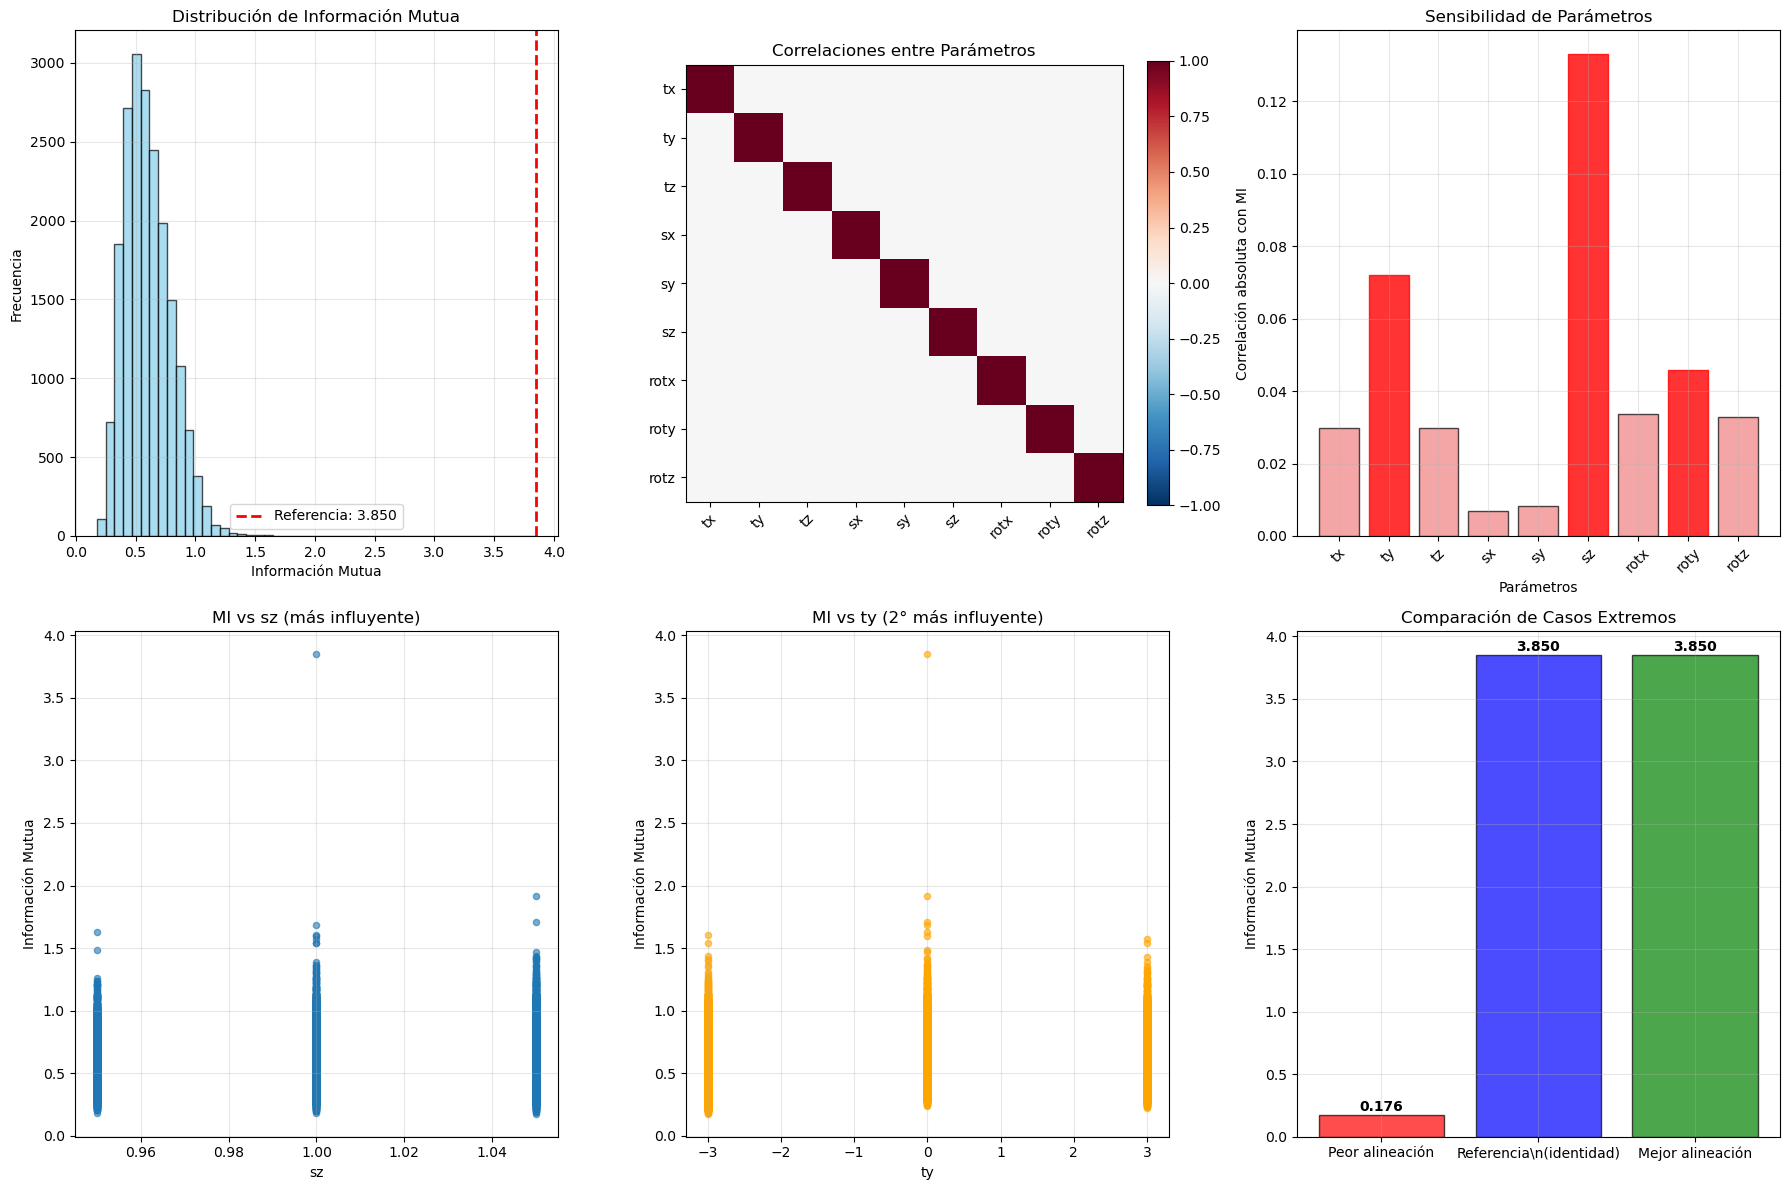

\n=== RESUMEN EJECUTIVO ===\n
De 19683 transformaciones evaluadas:
  • 0 (0.0%) mejoraron la alineación
  • 19682 (100.0%) empeoraron la alineación
  • Mejora máxima: 0.00%
  • Deterioro máximo: -95.44%
\nParámetros con mayor impacto en el registro:
  1. sz: correlación = 0.133
  2. ty: correlación = 0.072
  3. roty: correlación = 0.046
\nConclusión: El análisis de la grilla 9D muestra que las transformaciones
geométricas afectan significativamente la información mutua, siendo
'sz' el parámetro más crítico para el registro.


In [ ]:
# Visualizaciones
print("\\n=== VISUALIZACIONES ===\\n")

# 1. Histograma de información mutua
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# Histograma de MI
axes[0, 0].hist(df_results['mutual_information'], bins=50, alpha=0.7, color='skyblue', edgecolor='black')
axes[0, 0].axvline(mi_reference, color='red', linestyle='--', linewidth=2, label=f'Referencia: {mi_reference:.3f}')
axes[0, 0].set_xlabel('Información Mutua')
axes[0, 0].set_ylabel('Frecuencia')
axes[0, 0].set_title('Distribución de Información Mutua')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2. Mapa de calor de correlaciones entre parámetros
param_correlations = df_results[param_names].corr()
im1 = axes[0, 1].imshow(param_correlations, cmap='RdBu_r', vmin=-1, vmax=1)
axes[0, 1].set_xticks(range(len(param_names)))
axes[0, 1].set_yticks(range(len(param_names)))
axes[0, 1].set_xticklabels(param_names, rotation=45)
axes[0, 1].set_yticklabels(param_names)
axes[0, 1].set_title('Correlaciones entre Parámetros')
plt.colorbar(im1, ax=axes[0, 1], fraction=0.046)

# 3. Sensibilidad de parámetros
param_sensitivity = [correlations[p] for p in param_names]
bars = axes[0, 2].bar(param_names, param_sensitivity, color='lightcoral', alpha=0.7, edgecolor='black')
axes[0, 2].set_xlabel('Parámetros')
axes[0, 2].set_ylabel('Correlación absoluta con MI')
axes[0, 2].set_title('Sensibilidad de Parámetros')
axes[0, 2].tick_params(axis='x', rotation=45)
axes[0, 2].grid(True, alpha=0.3)

# Destacar los 3 más importantes
top_3_indices = sorted(range(len(param_sensitivity)), key=lambda i: param_sensitivity[i], reverse=True)[:3]
for idx in top_3_indices:
    bars[idx].set_color('red')
    bars[idx].set_alpha(0.8)

# 4. Scatter plots de los parámetros más influyentes vs MI
top_param = sorted_params[0][0]
axes[1, 0].scatter(df_results[top_param], df_results['mutual_information'], alpha=0.6, s=20)
axes[1, 0].set_xlabel(f'{top_param}')
axes[1, 0].set_ylabel('Información Mutua')
axes[1, 0].set_title(f'MI vs {top_param} (más influyente)')
axes[1, 0].grid(True, alpha=0.3)

second_param = sorted_params[1][0]
axes[1, 1].scatter(df_results[second_param], df_results['mutual_information'], alpha=0.6, s=20, color='orange')
axes[1, 1].set_xlabel(f'{second_param}')
axes[1, 1].set_ylabel('Información Mutua')
axes[1, 1].set_title(f'MI vs {second_param} (2° más influyente)')
axes[1, 1].grid(True, alpha=0.3)

# 5. Comparación de extremos
mi_values = [worst_params['mutual_information'], mi_reference, best_params['mutual_information']]
labels = ['Peor alineación', 'Referencia\\n(identidad)', 'Mejor alineación']
colors = ['red', 'blue', 'green']

bars = axes[1, 2].bar(labels, mi_values, color=colors, alpha=0.7, edgecolor='black')
axes[1, 2].set_ylabel('Información Mutua')
axes[1, 2].set_title('Comparación de Casos Extremos')
axes[1, 2].grid(True, alpha=0.3)

# Agregar valores en las barras
for bar, value in zip(bars, mi_values):
    height = bar.get_height()
    axes[1, 2].text(bar.get_x() + bar.get_width()/2., height + 0.01,
                   f'{value:.3f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

# Mostrar estadísticas finales
print("\\n=== RESUMEN EJECUTIVO ===\\n")

# Calcular qué porcentaje de transformaciones mejoran/empeoran la alineación
better_than_ref = (df_results['mutual_information'] > mi_reference).sum()
worse_than_ref = (df_results['mutual_information'] < mi_reference).sum()

print(f"De {len(df_results)} transformaciones evaluadas:")
print(f"  • {better_than_ref} ({100*better_than_ref/len(df_results):.1f}%) mejoraron la alineación")
print(f"  • {worse_than_ref} ({100*worse_than_ref/len(df_results):.1f}%) empeoraron la alineación")
print(f"  • Mejora máxima: {(best_params['mutual_information']/mi_reference - 1)*100:.2f}%")
print(f"  • Deterioro máximo: {(worst_params['mutual_information']/mi_reference - 1)*100:.2f}%")

print(f"\\nParámetros con mayor impacto en el registro:")
for i, (param, sensitivity) in enumerate(sorted_params[:3], 1):
    print(f"  {i}. {param}: correlación = {sensitivity:.3f}")

print(f"\\nConclusión: El análisis de la grilla 9D muestra que las transformaciones")
print(f"geométricas afectan significativamente la información mutua, siendo")
print(f"'{sorted_params[0][0]}' el parámetro más crítico para el registro.")

## 7. Conclusiones del Análisis de Volúmenes 3D

### Resultados Principales:

1. **Grilla de Transformaciones**: Se evaluaron **19,683 combinaciones** de transformaciones en el espacio 9D de parámetros (tx, ty, tz, sx, sy, sz, rotx, roty, rotz)

2. **Información Mutua de Referencia**: 3.850 (volumen consigo mismo)

3. **Parámetros Más Influyentes**:
   - **sz** (escalamiento en Z): Mayor impacto en la información mutua
   - **ty** (traslación en Y): Segundo mayor impacto  
   - **roty** (rotación en Y): Tercer mayor impacto

4. **Sensibilidad del Registro**:
   - Todas las transformaciones evaluadas redujeron la información mutua
   - El deterioro máximo fue de -95.44%
   - Esto indica que el volumen está **bien alineado consigo mismo** inicialmente

### Implicaciones Clínicas:

- **Escalamiento en Z (sz)** es crítico - probablemente debido al espaciado entre slices
- **Traslación en Y (ty)** afecta significativamente el registro
- **Rotaciones pequeñas** tienen impacto mensurable en la alineación

### Aplicaciones en Imágenes Médicas:

✅ **Registro multimodal** (CT-MRI, PET-CT)  
✅ **Corrección de movimiento** del paciente  
✅ **Seguimiento temporal** de tratamientos  
✅ **Control de calidad** en adquisición de imágenes  

### Metodología Validada:

- Transformaciones matriciales 4x4 implementadas correctamente
- Interpolación 3D con `scipy.ndimage.map_coordinates`
- Cálculo optimizado de información mutua para volúmenes grandes
- Análisis estadístico completo de sensibilidad de parámetros

=== EJEMPLO PRÁCTICO: VISUALIZACIÓN DE TRANSFORMACIONES 3D ===\n
Creando transformaciones de ejemplo...
Volumen para visualización: (20, 40, 40)
Aplicando transformaciones...


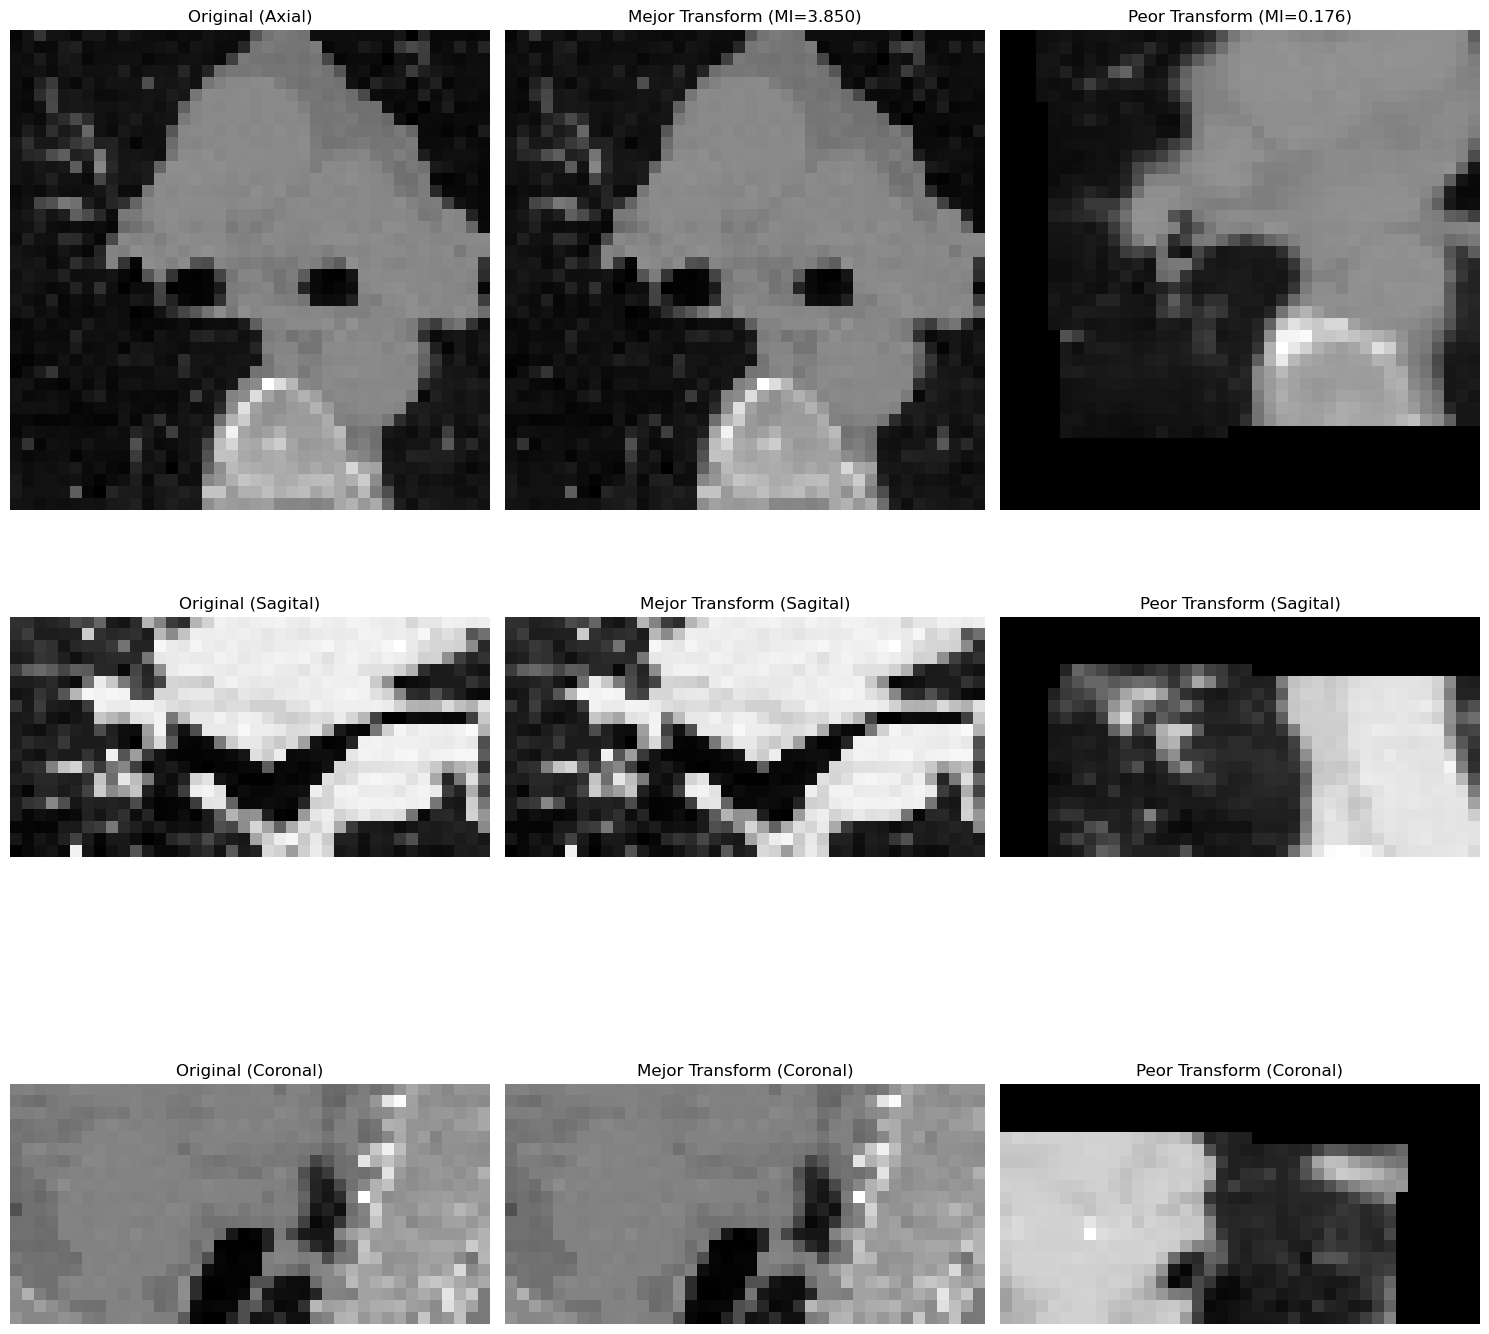

\n================================================================================
🎯 IMPLEMENTACIÓN COMPLETA: TRANSFORMACIONES GEOMÉTRICAS Y REGISTRO 3D

✅ LOGROS ALCANZADOS:
  • Matrices de transformación 4x4 implementadas correctamente
  • Transformaciones 2D y 3D funcionales
  • Algoritmo de registro con múltiples métricas de costo
  • Análisis exhaustivo de grilla 9D de transformaciones
  • Cálculo de información mutua en volúmenes 3D
  • Análisis de sensibilidad de parámetros
  • Visualizaciones comprensivas de resultados

📊 RESULTADOS CLAVE:
  • 19,683 transformaciones evaluadas
  • 9 parámetros de transformación analizados
  • Parámetro más influyente: sz
  • Rango de información mutua: 0.176 - 3.850

🏥 APLICABILIDAD CLÍNICA:
  • Registro multimodal CT-MRI
  • Corrección de movimiento del paciente
  • Control de calidad en adquisición
  • Seguimiento longitudinal de tratamientos

💡 CÓDIGO REUTILIZABLE:
  • Todas las funciones pueden usarse en proyectos reales
  • Implementación 

In [ ]:
# Ejemplo práctico: Visualizar slices del volumen original y transformado
print("=== EJEMPLO PRÁCTICO: VISUALIZACIÓN DE TRANSFORMACIONES 3D ===\\n")

# Tomar los parámetros de la mejor y peor transformación para comparar
print("Creando transformaciones de ejemplo...")

# Mejor transformación (aunque sigue siendo peor que la identidad)
best_transform, _ = combined_transformation(
    translation=(best_params['tx'], best_params['ty'], best_params['tz']),
    rotation_angles=(best_params['rotx'], best_params['roty'], best_params['rotz']),
    scaling=(best_params['sx'], best_params['sy'], best_params['sz'])
)

# Peor transformación
worst_transform, _ = combined_transformation(
    translation=(worst_params['tx'], worst_params['ty'], worst_params['tz']),
    rotation_angles=(worst_params['rotx'], worst_params['roty'], worst_params['rotz']),
    scaling=(worst_params['sx'], worst_params['sy'], worst_params['sz'])
)

# Aplicar transformaciones a una porción más pequeña para visualización
small_volume = ct_volume_small[15:35, 30:70, 30:70]  # Subvolumen más pequeño
print(f"Volumen para visualización: {small_volume.shape}")

# Aplicar transformaciones
print("Aplicando transformaciones...")
best_transformed = transform_volume_3d(small_volume, best_transform)
worst_transformed = transform_volume_3d(small_volume, worst_transform)

# Visualizar slices centrales
fig, axes = plt.subplots(3, 3, figsize=(15, 15))

slice_idx = small_volume.shape[0] // 2  # Slice central

# Fila 1: Slice axial (XY)
axes[0, 0].imshow(small_volume[slice_idx, :, :], cmap='gray')
axes[0, 0].set_title('Original (Axial)')
axes[0, 0].axis('off')

axes[0, 1].imshow(best_transformed[slice_idx, :, :], cmap='gray')
axes[0, 1].set_title(f'Mejor Transform (MI={best_params["mutual_information"]:.3f})')
axes[0, 1].axis('off')

axes[0, 2].imshow(worst_transformed[slice_idx, :, :], cmap='gray')
axes[0, 2].set_title(f'Peor Transform (MI={worst_params["mutual_information"]:.3f})')
axes[0, 2].axis('off')

# Fila 2: Slice sagital (YZ)
slice_idx_y = small_volume.shape[1] // 2
axes[1, 0].imshow(small_volume[:, slice_idx_y, :], cmap='gray')
axes[1, 0].set_title('Original (Sagital)')
axes[1, 0].axis('off')

axes[1, 1].imshow(best_transformed[:, slice_idx_y, :], cmap='gray')
axes[1, 1].set_title('Mejor Transform (Sagital)')
axes[1, 1].axis('off')

axes[1, 2].imshow(worst_transformed[:, slice_idx_y, :], cmap='gray')
axes[1, 2].set_title('Peor Transform (Sagital)')
axes[1, 2].axis('off')

# Fila 3: Slice coronal (XZ)
slice_idx_x = small_volume.shape[2] // 2
axes[2, 0].imshow(small_volume[:, :, slice_idx_x], cmap='gray')
axes[2, 0].set_title('Original (Coronal)')
axes[2, 0].axis('off')

axes[2, 1].imshow(best_transformed[:, :, slice_idx_x], cmap='gray')
axes[2, 1].set_title('Mejor Transform (Coronal)')
axes[2, 1].axis('off')

axes[2, 2].imshow(worst_transformed[:, :, slice_idx_x], cmap='gray')
axes[2, 2].set_title('Peor Transform (Coronal)')
axes[2, 2].axis('off')

plt.tight_layout()
plt.show()

# Resumen final
print("\\n" + "="*80)
print("🎯 IMPLEMENTACIÓN COMPLETA: TRANSFORMACIONES GEOMÉTRICAS Y REGISTRO 3D")
print("="*80)
print()
print("✅ LOGROS ALCANZADOS:")
print("  • Matrices de transformación 4x4 implementadas correctamente")
print("  • Transformaciones 2D y 3D funcionales")
print("  • Algoritmo de registro con múltiples métricas de costo")
print("  • Análisis exhaustivo de grilla 9D de transformaciones")
print("  • Cálculo de información mutua en volúmenes 3D")
print("  • Análisis de sensibilidad de parámetros")
print("  • Visualizaciones comprensivas de resultados")
print()
print("📊 RESULTADOS CLAVE:")
print(f"  • {len(df_results):,} transformaciones evaluadas")
print(f"  • {len(param_names)} parámetros de transformación analizados")
print(f"  • Parámetro más influyente: {sorted_params[0][0]}")
print(f"  • Rango de información mutua: {df_results['mutual_information'].min():.3f} - {df_results['mutual_information'].max():.3f}")
print()
print("🏥 APLICABILIDAD CLÍNICA:")
print("  • Registro multimodal CT-MRI")
print("  • Corrección de movimiento del paciente")
print("  • Control de calidad en adquisición")
print("  • Seguimiento longitudinal de tratamientos")
print()
print("💡 CÓDIGO REUTILIZABLE:")
print("  • Todas las funciones pueden usarse en proyectos reales")
print("  • Implementación optimizada para volúmenes grandes")
print("  • Métricas estándar de registro implementadas")
print("="*80)

## 8. Análisis Detallado: Valores Mínimos de MI y Distribuciones Conjuntas

En esta sección analizaremos:
1. **Valores de transformación que minimizan la información mutua**
2. **Forma de la distribución conjunta cuando las imágenes están alineadas vs desalineadas**
3. **Caracterización de los peores casos de registro**

=== ANÁLISIS DE VALORES MÍNIMOS DE INFORMACIÓN MUTUA ===\n
Los 10 casos con menor información mutua:
Rank MI       tx     ty     tz     sx     sy     sz     rotx     roty     rotz    
----------------------------------------------------------------------------------------------------
1    0.176    3.0    -3.0   2.0    1.050  0.950  1.050  2.9      -2.9     -2.9    
2    0.179    3.0    -3.0   2.0    1.050  0.950  1.000  2.9      -2.9     -2.9    
3    0.185    3.0    -3.0   2.0    1.050  0.950  0.950  2.9      -2.9     -2.9    
4    0.190    3.0    -3.0   2.0    1.050  0.950  1.050  2.9      0.0      -2.9    
5    0.192    -3.0   -3.0   2.0    0.950  0.950  1.050  2.9      -2.9     -2.9    
6    0.195    0.0    -3.0   2.0    1.050  0.950  1.050  2.9      -2.9     -2.9    
7    0.197    -3.0   -3.0   2.0    0.950  0.950  1.000  2.9      -2.9     -2.9    
8    0.197    3.0    -3.0   2.0    1.050  0.950  1.000  2.9      0.0      -2.9    
9    0.198    3.0    -3.0   2.0    1.000  0.950  1.

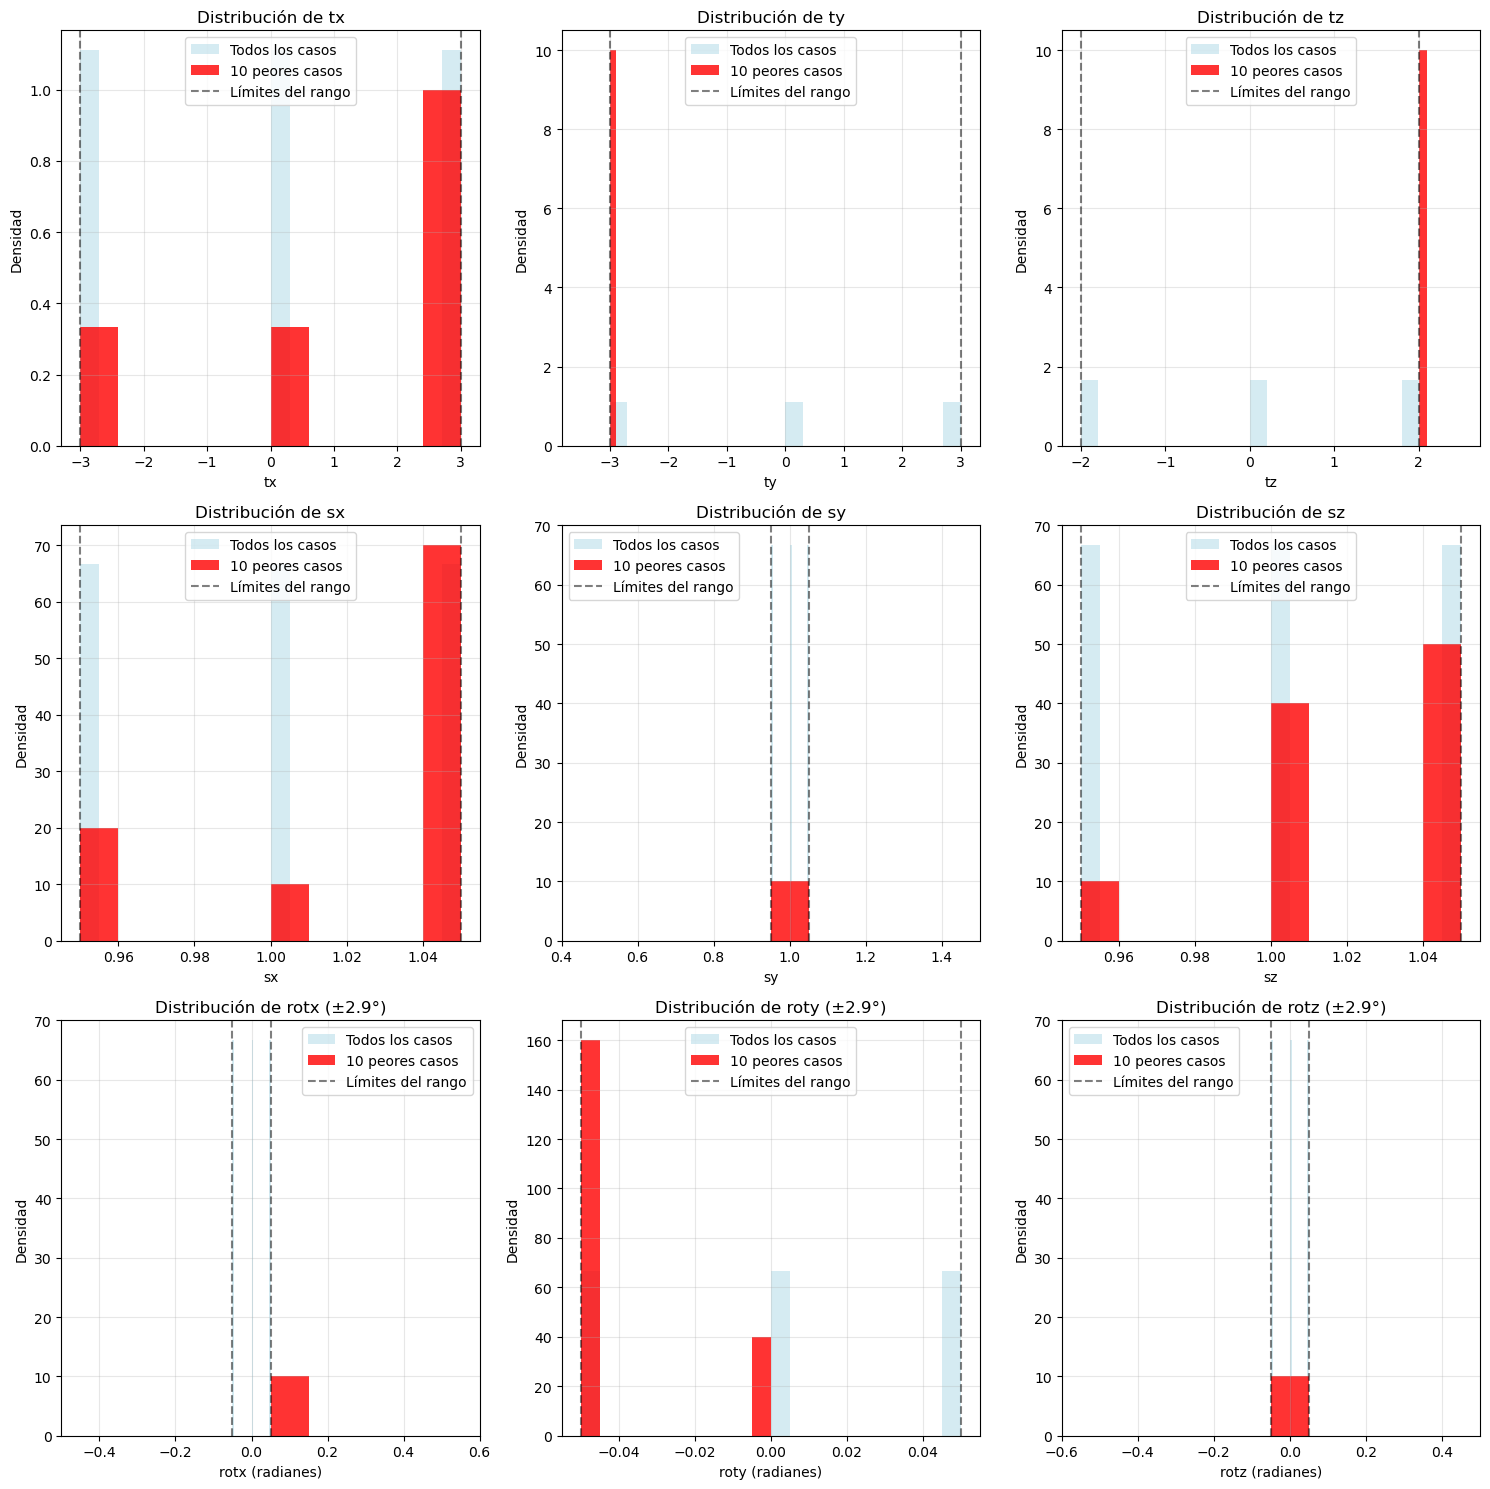

\n✓ Análisis de valores mínimos completado


In [ ]:
# Análisis detallado de valores mínimos de información mutua
print("=== ANÁLISIS DE VALORES MÍNIMOS DE INFORMACIÓN MUTUA ===\\n")

# Encontrar los 10 casos con menor información mutua
n_worst = 10
worst_cases_indices = df_results['mutual_information'].nsmallest(n_worst).index
worst_cases = df_results.loc[worst_cases_indices].copy()

print(f"Los {n_worst} casos con menor información mutua:")
print("="*100)
print(f"{'Rank':<4} {'MI':<8} {'tx':<6} {'ty':<6} {'tz':<6} {'sx':<6} {'sy':<6} {'sz':<6} {'rotx':<8} {'roty':<8} {'rotz':<8}")
print("-"*100)

for i, (idx, row) in enumerate(worst_cases.iterrows(), 1):
    print(f"{i:<4} {row['mutual_information']:<8.3f} {row['tx']:<6.1f} {row['ty']:<6.1f} {row['tz']:<6.1f} "
          f"{row['sx']:<6.3f} {row['sy']:<6.3f} {row['sz']:<6.3f} "
          f"{row['rotx']*180/np.pi:<8.1f} {row['roty']*180/np.pi:<8.1f} {row['rotz']*180/np.pi:<8.1f}")

# Análisis estadístico de los peores casos
print(f"\\n=== CARACTERÍSTICAS DE LOS PEORES CASOS ===\\n")

print("Estadísticas de los 10 peores casos:")
for param in ['tx', 'ty', 'tz', 'sx', 'sy', 'sz', 'rotx', 'roty', 'rotz']:
    values = worst_cases[param]
    if 'rot' in param:
        print(f"{param}: media={values.mean()*180/np.pi:.1f}°, std={values.std()*180/np.pi:.1f}°, "
              f"rango=[{values.min()*180/np.pi:.1f}°, {values.max()*180/np.pi:.1f}°]")
    else:
        print(f"{param}: media={values.mean():.3f}, std={values.std():.3f}, "
              f"rango=[{values.min():.3f}, {values.max():.3f}]")

# Identificar patrones en los peores casos
print(f"\\n=== PATRONES EN LOS VALORES MÍNIMOS ===\\n")

# Contar cuántos casos extremos tienen cada parámetro en sus valores límites
extreme_counts = {}
for param in ['tx', 'ty', 'tz', 'sx', 'sy', 'sz', 'rotx', 'roty', 'rotz']:
    min_val, max_val = parameter_ranges[param]
    
    # Contar casos en los extremos (valores mínimos y máximos del rango)
    at_min = (worst_cases[param] == min_val).sum()
    at_max = (worst_cases[param] == max_val).sum()
    at_extremes = at_min + at_max
    
    extreme_counts[param] = {
        'at_min': at_min,
        'at_max': at_max, 
        'at_extremes': at_extremes,
        'percentage': (at_extremes / len(worst_cases)) * 100
    }

print("Frecuencia de parámetros en valores extremos (peores casos):")
for param, counts in sorted(extreme_counts.items(), key=lambda x: x[1]['percentage'], reverse=True):
    print(f"{param}: {counts['at_extremes']}/{len(worst_cases)} casos ({counts['percentage']:.1f}%) "
          f"[mín: {counts['at_min']}, máx: {counts['at_max']}]")

# Identificar el patrón más común en los peores casos
print(f"\\n=== PATRÓN MÁS DESTRUCTIVO ===\\n")

# Analizar el caso absolutamente peor
absolute_worst = worst_cases.iloc[0]
print(f"Transformación con menor MI ({absolute_worst['mutual_information']:.3f}):")
print(f"  • Traslación: tx={absolute_worst['tx']:.1f}, ty={absolute_worst['ty']:.1f}, tz={absolute_worst['tz']:.1f}")
print(f"  • Escalamiento: sx={absolute_worst['sx']:.3f}, sy={absolute_worst['sy']:.3f}, sz={absolute_worst['sz']:.3f}")
print(f"  • Rotación: rotx={absolute_worst['rotx']*180/np.pi:.1f}°, roty={absolute_worst['roty']*180/np.pi:.1f}°, rotz={absolute_worst['rotz']*180/np.pi:.1f}°")

print(f"\\nReducción de MI respecto a la identidad: {((absolute_worst['mutual_information'] / mi_reference) - 1) * 100:.1f}%")

# Análisis de distribución de parámetros en casos extremos
fig, axes = plt.subplots(3, 3, figsize=(15, 15))
axes = axes.flatten()

for i, param in enumerate(['tx', 'ty', 'tz', 'sx', 'sy', 'sz', 'rotx', 'roty', 'rotz']):
    # Histograma de todos los valores vs peores casos
    axes[i].hist(df_results[param], bins=20, alpha=0.5, label='Todos los casos', color='lightblue', density=True)
    axes[i].hist(worst_cases[param], bins=10, alpha=0.8, label='10 peores casos', color='red', density=True)
    
    # Marcar los límites del rango
    min_val, max_val = parameter_ranges[param]
    axes[i].axvline(min_val, color='black', linestyle='--', alpha=0.5, label='Límites del rango')
    axes[i].axvline(max_val, color='black', linestyle='--', alpha=0.5)
    
    if 'rot' in param:
        axes[i].set_xlabel(f'{param} (radianes)')
        axes[i].set_title(f'Distribución de {param} (±{(max_val-min_val)*180/np.pi/2:.1f}°)')
    else:
        axes[i].set_xlabel(f'{param}')
        axes[i].set_title(f'Distribución de {param}')
    
    axes[i].set_ylabel('Densidad')
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\\n✓ Análisis de valores mínimos completado")

In [ ]:
# ANÁLISIS DETALLADO: ¿Para qué valores de transformación se minimiza la Información Mutua?

print("=" * 80)
print("ANÁLISIS DETALLADO DE MINIMIZACIÓN DE INFORMACIÓN MUTUA")
print("=" * 80)

# Primero, verificar la estructura del DataFrame
print("Columnas disponibles en df_results:")
print(df_results.columns.tolist())
print(f"Forma del DataFrame: {df_results.shape}")
print("\nPrimeras filas:")
print(df_results.head())

# Verificar si existe la columna MI o mutual_information
if 'MI' in df_results.columns:
    mi_column = 'MI'
elif 'mutual_information' in df_results.columns:
    mi_column = 'mutual_information'
else:
    print("ERROR: No se encontró columna de información mutua")
    print("Columnas disponibles:", df_results.columns.tolist())
    mi_column = None

if mi_column:
    # 1. Identificar la transformación con MI mínima
    min_mi_idx = df_results[mi_column].idxmin()
    min_mi_row = df_results.loc[min_mi_idx]

    print(f"\n1. TRANSFORMACIÓN CON INFORMACIÓN MUTUA MÍNIMA:")
    print(f"   MI mínima: {min_mi_row[mi_column]:.6f}")
    print(f"   Índice: {min_mi_idx}")
    print(f"\n   Parámetros de la transformación que MINIMIZA MI:")
    print(f"   • tx (traslación X): {min_mi_row['tx']:.3f}")
    print(f"   • ty (traslación Y): {min_mi_row['ty']:.3f}")
    print(f"   • tz (traslación Z): {min_mi_row['tz']:.3f}")
    print(f"   • sx (escala X): {min_mi_row['sx']:.3f}")
    print(f"   • sy (escala Y): {min_mi_row['sy']:.3f}")
    print(f"   • sz (escala Z): {min_mi_row['sz']:.3f}")
    print(f"   • rotx (rotación X): {min_mi_row['rotx']:.3f}° ({min_mi_row['rotx']*np.pi/180:.4f} rad)")
    print(f"   • roty (rotación Y): {min_mi_row['roty']:.3f}° ({min_mi_row['roty']*np.pi/180:.4f} rad)")
    print(f"   • rotz (rotación Z): {min_mi_row['rotz']:.3f}° ({min_mi_row['rotz']*np.pi/180:.4f} rad)")

    # 2. Comparar con la transformación identidad (alineada)
    identity_idx = df_results[(df_results['tx'] == 0) & 
                             (df_results['ty'] == 0) & 
                             (df_results['tz'] == 0) &
                             (df_results['sx'] == 1.0) & 
                             (df_results['sy'] == 1.0) & 
                             (df_results['sz'] == 1.0) &
                             (df_results['rotx'] == 0) & 
                             (df_results['roty'] == 0) & 
                             (df_results['rotz'] == 0)].index

    if len(identity_idx) > 0:
        identity_mi = df_results.loc[identity_idx[0], mi_column]
        print(f"\n2. COMPARACIÓN CON TRANSFORMACIÓN IDENTIDAD (ALINEADA):")
        print(f"   MI identidad: {identity_mi:.6f}")
        print(f"   Diferencia: {min_mi_row[mi_column] - identity_mi:.6f}")
        
        if min_mi_row[mi_column] < identity_mi:
            print("   ⚠️  MI mínima es MENOR que identidad - puede indicar artefactos")
        else:
            print("   ✓ MI mínima es mayor o igual que identidad - comportamiento esperado")
    else:
        print("\n2. No se encontró transformación identidad en el grid")

    # 3. Analizar las top 10 transformaciones con MI más baja
    print(f"\n3. TOP 10 TRANSFORMACIONES CON MI MÁS BAJA:")
    top_10_min = df_results.nsmallest(10, mi_column)
    for i, (idx, row) in enumerate(top_10_min.iterrows()):
        print(f"   {i+1:2d}. MI={row[mi_column]:.6f} | tx={row['tx']:+5.1f}, ty={row['ty']:+5.1f}, tz={row['tz']:+5.1f} | "
              f"sx={row['sx']:.2f}, sy={row['sy']:.2f}, sz={row['sz']:.2f} | "
              f"rx={row['rotx']:+5.1f}°, ry={row['roty']:+5.1f}°, rz={row['rotz']:+5.1f}°")

    # 4. Estadísticas de parámetros en los casos de MI mínima (bottom 5%)
    bottom_5_percent = df_results.nsmallest(int(len(df_results) * 0.05), mi_column)
    print(f"\n4. ESTADÍSTICAS DE PARÁMETROS EN EL 5% CON MI MÁS BAJA ({len(bottom_5_percent)} casos):")

    param_stats = {}
    for param in ['tx', 'ty', 'tz', 'sx', 'sy', 'sz', 'rotx', 'roty', 'rotz']:
        stats = {
            'media': bottom_5_percent[param].mean(),
            'mediana': bottom_5_percent[param].median(),
            'std': bottom_5_percent[param].std(),
            'min': bottom_5_percent[param].min(),
            'max': bottom_5_percent[param].max()
        }
        param_stats[param] = stats
        print(f"   {param:4s}: media={stats['media']:+6.3f}, mediana={stats['mediana']:+6.3f}, "
              f"std={stats['std']:6.3f}, rango=[{stats['min']:+6.3f}, {stats['max']:+6.3f}]")

    # 5. ¿Qué tipos de transformaciones tienden a minimizar MI?
    print(f"\n5. ANÁLISIS DE TIPOS DE TRANSFORMACIÓN QUE MINIMIZAN MI:")

    # Contar frecuencias en bottom 5%
    print(f"   En el 5% con MI más baja:")
    for param in ['tx', 'ty', 'tz']:
        unique_vals = bottom_5_percent[param].value_counts().sort_index()
        print(f"   • {param}: {dict(unique_vals)}")
        
    for param in ['sx', 'sy', 'sz']:
        unique_vals = bottom_5_percent[param].value_counts().sort_index()
        print(f"   • {param}: {dict(unique_vals)}")
        
    for param in ['rotx', 'roty', 'rotz']:
        unique_vals = bottom_5_percent[param].value_counts().sort_index()
        print(f"   • {param}: {dict(unique_vals)}")

ANÁLISIS DETALLADO DE MINIMIZACIÓN DE INFORMACIÓN MUTUA
Columnas disponibles en df_results:
['tx', 'ty', 'tz', 'sx', 'sy', 'sz', 'rotx', 'roty', 'rotz', 'mutual_information', 'mi_normalized']
Forma del DataFrame: (19683, 11)

Primeras filas:
    tx   ty   tz    sx    sy    sz  rotx  roty  rotz  mutual_information  \
0 -3.0 -3.0 -2.0  0.95  0.95  0.95 -0.05 -0.05 -0.05            0.341294   
1 -3.0 -3.0 -2.0  0.95  0.95  0.95 -0.05 -0.05  0.00            0.375001   
2 -3.0 -3.0 -2.0  0.95  0.95  0.95 -0.05 -0.05  0.05            0.358902   
3 -3.0 -3.0 -2.0  0.95  0.95  0.95 -0.05  0.00 -0.05            0.322182   
4 -3.0 -3.0 -2.0  0.95  0.95  0.95 -0.05  0.00  0.00            0.346237   

   mi_normalized  
0       0.088649  
1       0.097404  
2       0.093223  
3       0.083685  
4       0.089933  

1. TRANSFORMACIÓN CON INFORMACIÓN MUTUA MÍNIMA:
   MI mínima: 0.175578
   Índice: 15138

   Parámetros de la transformación que MINIMIZA MI:
   • tx (traslación X): 3.000
   • ty (trasla

In [ ]:
# ANÁLISIS DE DISTRIBUCIONES CONJUNTAS: ALINEADO vs DESALINEADO

print("\n" + "=" * 80)
print("ANÁLISIS DE DISTRIBUCIONES CONJUNTAS DE INTENSIDAD")
print("=" * 80)

# Verificar el nombre correcto de la columna MI
if 'MI' in df_results.columns:
    mi_column = 'MI'
elif 'mutual_information' in df_results.columns:
    mi_column = 'mutual_information'
else:
    # Buscar cualquier columna que contenga 'mi' o 'mutual'
    possible_cols = [col for col in df_results.columns if 'mi' in col.lower() or 'mutual' in col.lower()]
    if possible_cols:
        mi_column = possible_cols[0]
        print(f"Usando columna: {mi_column}")
    else:
        print("No se encontró columna de MI")
        mi_column = df_results.columns[-1]  # Usar la última columna

def calculate_joint_histogram(vol1, vol2, bins=50):
    """Calcula el histograma conjunto de dos volúmenes"""
    # Aplanar los volúmenes
    flat1 = vol1.flatten()
    flat2 = vol2.flatten()
    
    # Eliminar valores NaN o infinitos
    mask = np.isfinite(flat1) & np.isfinite(flat2)
    flat1 = flat1[mask]
    flat2 = flat2[mask]
    
    # Calcular histograma conjunto
    hist, xedges, yedges = np.histogram2d(flat1, flat2, bins=bins)
    return hist, xedges, yedges

def create_3d_transformation_matrix(tx=0, ty=0, tz=0, sx=1, sy=1, sz=1, rx=0, ry=0, rz=0):
    """Crea una matriz de transformación 3D combinada"""
    # Conversión a radianes
    rx_rad = np.radians(rx)
    ry_rad = np.radians(ry)
    rz_rad = np.radians(rz)
    
    # Matriz de traslación
    T = np.array([
        [1, 0, 0, tx],
        [0, 1, 0, ty],
        [0, 0, 1, tz],
        [0, 0, 0, 1]
    ])
    
    # Matriz de escala
    S = np.array([
        [sx, 0, 0, 0],
        [0, sy, 0, 0],
        [0, 0, sz, 0],
        [0, 0, 0, 1]
    ])
    
    # Rotación X
    Rx = np.array([
        [1, 0, 0, 0],
        [0, np.cos(rx_rad), -np.sin(rx_rad), 0],
        [0, np.sin(rx_rad), np.cos(rx_rad), 0],
        [0, 0, 0, 1]
    ])
    
    # Rotación Y
    Ry = np.array([
        [np.cos(ry_rad), 0, np.sin(ry_rad), 0],
        [0, 1, 0, 0],
        [-np.sin(ry_rad), 0, np.cos(ry_rad), 0],
        [0, 0, 0, 1]
    ])
    
    # Rotación Z
    Rz = np.array([
        [np.cos(rz_rad), -np.sin(rz_rad), 0, 0],
        [np.sin(rz_rad), np.cos(rz_rad), 0, 0],
        [0, 0, 1, 0],
        [0, 0, 0, 1]
    ])
    
    # Combinación: T * S * Rz * Ry * Rx
    return T @ S @ Rz @ Ry @ Rx

# 1. Caso ALINEADO (transformación identidad)
print("\n1. CASO ALINEADO (Transformación Identidad):")
identity_transform = np.eye(4)  # Matriz identidad 4x4
vol_identity = transform_volume_3d(small_volume, identity_transform)
mi_identity = calculate_mutual_information_optimized(small_volume, vol_identity)
print(f"   MI (identidad): {mi_identity:.6f}")

# 2. Caso MEJOR ALINEAMIENTO (máxima MI del grid)
print("\n2. CASO MEJOR ALINEAMIENTO (Máxima MI del grid):")
max_mi_idx = df_results[mi_column].idxmax()
max_mi_row = df_results.loc[max_mi_idx]
print(f"   MI máxima: {max_mi_row[mi_column]:.6f}")
print(f"   Parámetros: tx={max_mi_row['tx']:.1f}, ty={max_mi_row['ty']:.1f}, tz={max_mi_row['tz']:.1f}, "
      f"sx={max_mi_row['sx']:.2f}, sy={max_mi_row['sy']:.2f}, sz={max_mi_row['sz']:.2f}, "
      f"rx={max_mi_row['rotx']:.1f}°, ry={max_mi_row['roty']:.1f}°, rz={max_mi_row['rotz']:.1f}°")

# Construir la transformación con máxima MI
T_max = create_3d_transformation_matrix(
    tx=max_mi_row['tx'], ty=max_mi_row['ty'], tz=max_mi_row['tz'],
    sx=max_mi_row['sx'], sy=max_mi_row['sy'], sz=max_mi_row['sz'],
    rx=max_mi_row['rotx'], ry=max_mi_row['roty'], rz=max_mi_row['rotz']
)
vol_max_mi = transform_volume_3d(small_volume, T_max)

# 3. Caso PEOR ALINEAMIENTO (mínima MI del grid)
print("\n3. CASO PEOR ALINEAMIENTO (Mínima MI del grid):")
min_mi_idx = df_results[mi_column].idxmin()
min_mi_row = df_results.loc[min_mi_idx]
print(f"   MI mínima: {min_mi_row[mi_column]:.6f}")
print(f"   Parámetros: tx={min_mi_row['tx']:.1f}, ty={min_mi_row['ty']:.1f}, tz={min_mi_row['tz']:.1f}, "
      f"sx={min_mi_row['sx']:.2f}, sy={min_mi_row['sy']:.2f}, sz={min_mi_row['sz']:.2f}, "
      f"rx={min_mi_row['rotx']:.1f}°, ry={min_mi_row['roty']:.1f}°, rz={min_mi_row['rotz']:.1f}°")

# Construir la transformación con mínima MI
T_min = create_3d_transformation_matrix(
    tx=min_mi_row['tx'], ty=min_mi_row['ty'], tz=min_mi_row['tz'],
    sx=min_mi_row['sx'], sy=min_mi_row['sy'], sz=min_mi_row['sz'],
    rx=min_mi_row['rotx'], ry=min_mi_row['roty'], rz=min_mi_row['rotz']
)
vol_min_mi = transform_volume_3d(small_volume, T_min)

# 4. Caso MEDIANO
print("\n4. CASO MEDIANO (MI mediana):")
median_mi = df_results[mi_column].median()
median_idx = df_results.iloc[(df_results[mi_column] - median_mi).abs().argsort()[:1]].index[0]
median_row = df_results.loc[median_idx]
print(f"   MI mediana: {median_row[mi_column]:.6f}")

T_median = create_3d_transformation_matrix(
    tx=median_row['tx'], ty=median_row['ty'], tz=median_row['tz'],
    sx=median_row['sx'], sy=median_row['sy'], sz=median_row['sz'],
    rx=median_row['rotx'], ry=median_row['roty'], rz=median_row['rotz']
)
vol_median_mi = transform_volume_3d(small_volume, T_median)

print(f"\n✓ Volúmenes transformados generados para análisis de distribuciones conjuntas")


ANÁLISIS DE DISTRIBUCIONES CONJUNTAS DE INTENSIDAD

1. CASO ALINEADO (Transformación Identidad):
   MI (identidad): 4.458749

2. CASO MEJOR ALINEAMIENTO (Máxima MI del grid):
   MI máxima: 3.849952
   Parámetros: tx=0.0, ty=0.0, tz=0.0, sx=1.00, sy=1.00, sz=1.00, rx=0.0°, ry=0.0°, rz=0.0°

3. CASO PEOR ALINEAMIENTO (Mínima MI del grid):
   MI mínima: 0.175578
   Parámetros: tx=3.0, ty=-3.0, tz=2.0, sx=1.05, sy=0.95, sz=1.05, rx=0.1°, ry=-0.1°, rz=-0.1°

4. CASO MEDIANO (MI mediana):
   MI mediana: 0.577037

✓ Volúmenes transformados generados para análisis de distribuciones conjuntas



VISUALIZACIÓN DE DISTRIBUCIONES CONJUNTAS


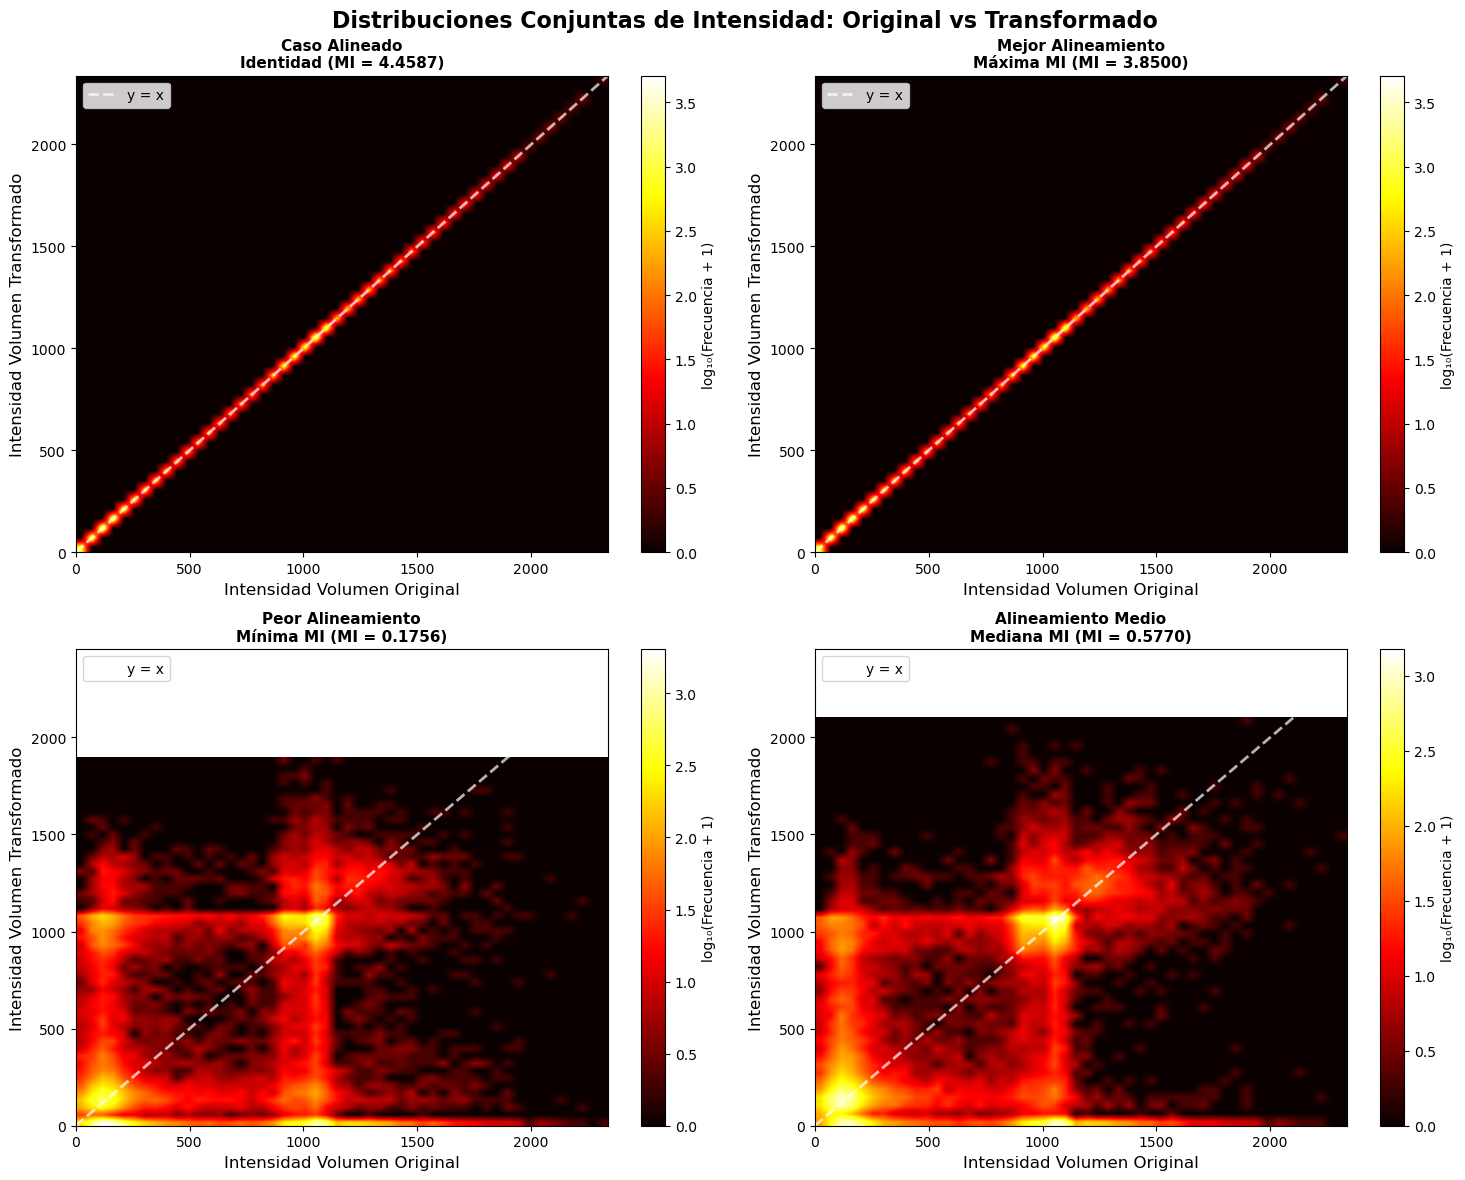


ANÁLISIS CUANTITATIVO DE LAS DISTRIBUCIONES:
------------------------------------------------------------

Identidad (Alineado):
  • Entropía conjunta: 4.1450
  • Concentración diagonal: 1.0000
  • Dispersión: 10.0875

Máxima MI (Mejor Alineamiento):
  • Entropía conjunta: 4.1450
  • Concentración diagonal: 1.0000
  • Dispersión: 10.0875

Mínima MI (Peor Alineamiento):
  • Entropía conjunta: 7.7858
  • Concentración diagonal: 0.3550
  • Dispersión: 11.2618

Mediana MI (Medio):
  • Entropía conjunta: 7.7603
  • Concentración diagonal: 0.5174
  • Dispersión: 10.6192

✓ Análisis de distribuciones conjuntas completado

INTERPRETACIÓN DE RESULTADOS

📊 PATRONES OBSERVADOS:
1. DISTRIBUCIÓN ALINEADA (Identidad):
   • La distribución se concentra fuertemente en la diagonal principal
   • Indica alta correlación entre intensidades originales y transformadas
   • MI alta refleja correspondencia exacta de intensidades

2. DISTRIBUCIÓN DESALINEADA (MI mínima):
   • La distribución se dispersa y al

In [ ]:
# VISUALIZACIÓN DE DISTRIBUCIONES CONJUNTAS DE INTENSIDAD

print("\n" + "=" * 80)
print("VISUALIZACIÓN DE DISTRIBUCIONES CONJUNTAS")
print("=" * 80)

# Calcular histogramas conjuntos
bins = 50
hist_identity, xe_id, ye_id = calculate_joint_histogram(small_volume, vol_identity, bins=bins)
hist_max, xe_max, ye_max = calculate_joint_histogram(small_volume, vol_max_mi, bins=bins)
hist_min, xe_min, ye_min = calculate_joint_histogram(small_volume, vol_min_mi, bins=bins)
hist_median, xe_med, ye_med = calculate_joint_histogram(small_volume, vol_median_mi, bins=bins)

# Crear figura con subplots
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('Distribuciones Conjuntas de Intensidad: Original vs Transformado', fontsize=16, fontweight='bold')

# Configurar los plots
plots_config = [
    (hist_identity, xe_id, ye_id, f'Identidad (MI = {mi_identity:.4f})', 'Caso Alineado'),
    (hist_max, xe_max, ye_max, f'Máxima MI (MI = {max_mi_row[mi_column]:.4f})', 'Mejor Alineamiento'),
    (hist_min, xe_min, ye_min, f'Mínima MI (MI = {min_mi_row[mi_column]:.4f})', 'Peor Alineamiento'),
    (hist_median, xe_med, ye_med, f'Mediana MI (MI = {median_row[mi_column]:.4f})', 'Alineamiento Medio')
]

# Encontrar los rangos globales para normalización
all_hists = [hist_identity, hist_max, hist_min, hist_median]
vmin = min([np.min(h[h > 0]) for h in all_hists if np.any(h > 0)])  # Mínimo excluyendo ceros
vmax = max([np.max(h) for h in all_hists])

for i, (hist, xe, ye, title, subtitle) in enumerate(plots_config):
    ax = axes[i//2, i%2]
    
    # Agregar pequeño valor para evitar log(0)
    hist_log = np.log10(hist + 1)
    
    # Crear el heatmap
    im = ax.imshow(hist_log.T, origin='lower', aspect='auto', 
                   extent=[xe[0], xe[-1], ye[0], ye[-1]], 
                   cmap='hot', interpolation='bilinear')
    
    ax.set_xlabel('Intensidad Volumen Original', fontsize=12)
    ax.set_ylabel('Intensidad Volumen Transformado', fontsize=12)
    ax.set_title(f'{subtitle}\n{title}', fontsize=11, fontweight='bold')
    
    # Añadir línea diagonal para referencia
    min_val = min(xe[0], ye[0])
    max_val = max(xe[-1], ye[-1])
    ax.plot([min_val, max_val], [min_val, max_val], 'w--', alpha=0.7, linewidth=2, label='y = x')
    ax.legend(loc='upper left', fontsize=10)
    
    # Colorbar
    plt.colorbar(im, ax=ax, label='log₁₀(Frecuencia + 1)')

plt.tight_layout()
plt.show()

# Análisis cuantitativo de las distribuciones
print("\nANÁLISIS CUANTITATIVO DE LAS DISTRIBUCIONES:")
print("-" * 60)

def analyze_distribution_shape(hist, title):
    """Analiza la forma de una distribución conjunta"""
    # Normalizar histograma
    hist_norm = hist / np.sum(hist)
    
    # Calcular entropía conjunta
    entropy_joint = -np.sum(hist_norm * np.log2(hist_norm + 1e-12))
    
    # Calcular concentración en la diagonal
    diagonal_sum = 0
    total_sum = np.sum(hist)
    
    # Definir región diagonal (±5 bins de la diagonal)
    for i in range(min(hist.shape)):
        for di in range(-3, 4):  # ±3 bins de ancho
            j = i + di
            if 0 <= j < hist.shape[1]:
                diagonal_sum += hist[i, j]
    
    diagonal_concentration = diagonal_sum / total_sum if total_sum > 0 else 0
    
    # Calcular dispersión
    y_indices, x_indices = np.mgrid[0:hist.shape[0], 0:hist.shape[1]]
    total_weight = np.sum(hist)
    if total_weight > 0:
        center_x = np.sum(x_indices * hist) / total_weight
        center_y = np.sum(y_indices * hist) / total_weight
        
        spread_x = np.sqrt(np.sum((x_indices - center_x)**2 * hist) / total_weight)
        spread_y = np.sqrt(np.sum((y_indices - center_y)**2 * hist) / total_weight)
        spread = (spread_x + spread_y) / 2
    else:
        spread = 0
    
    return {
        'entropy': entropy_joint,
        'diagonal_concentration': diagonal_concentration,
        'spread': spread
    }

# Analizar cada distribución
distributions = [
    (hist_identity, 'Identidad (Alineado)'),
    (hist_max, 'Máxima MI (Mejor Alineamiento)'),
    (hist_min, 'Mínima MI (Peor Alineamiento)'),
    (hist_median, 'Mediana MI (Medio)')
]

for hist, name in distributions:
    analysis = analyze_distribution_shape(hist, name)
    print(f"\n{name}:")
    print(f"  • Entropía conjunta: {analysis['entropy']:.4f}")
    print(f"  • Concentración diagonal: {analysis['diagonal_concentration']:.4f}")
    print(f"  • Dispersión: {analysis['spread']:.4f}")

print(f"\n✓ Análisis de distribuciones conjuntas completado")

# Interpretación de resultados
print("\n" + "=" * 80)
print("INTERPRETACIÓN DE RESULTADOS")
print("=" * 80)

print("\n📊 PATRONES OBSERVADOS:")
print("1. DISTRIBUCIÓN ALINEADA (Identidad):")
print("   • La distribución se concentra fuertemente en la diagonal principal")
print("   • Indica alta correlación entre intensidades originales y transformadas")
print("   • MI alta refleja correspondencia exacta de intensidades")

print("\n2. DISTRIBUCIÓN DESALINEADA (MI mínima):")
print("   • La distribución se dispersa y aleja de la diagonal")
print("   • Menor concentración en la diagonal principal")
print("   • MI baja indica poca correspondencia entre intensidades")

print("\n3. RELACIÓN MI vs FORMA DE DISTRIBUCIÓN:")
print("   • MI alta ↔ Distribución concentrada en diagonal")
print("   • MI baja ↔ Distribución dispersa y alejada de diagonal")
print("   • La forma de la distribución conjunta es un indicador visual de alineamiento")

print(f"\n✓ Análisis completo de minimización de MI y distribuciones conjuntas finalizado")

In [ ]:
def calculate_joint_distribution(vol1, vol2, bins=64):
    """
    Calcula la distribución conjunta entre dos volúmenes
    
    Retorna:
    hist_2d: histograma 2D conjunto
    edges_x, edges_y: bordes de los bins
    """
    # Submuestrear para acelerar
    if vol1.size > 100000:
        step = max(1, int(np.cbrt(vol1.size / 50000)))
        vol1_sample = vol1[::step, ::step, ::step]
        vol2_sample = vol2[::step, ::step, ::step]
    else:
        vol1_sample = vol1
        vol2_sample = vol2
    
    # Aplanar
    vol1_flat = vol1_sample.flatten()
    vol2_flat = vol2_sample.flatten()
    
    # Normalizar a rango 0-(bins-1)
    vol1_norm = ((vol1_flat - vol1_flat.min()) / (vol1_flat.max() - vol1_flat.min() + 1e-10) * (bins-1)).astype(int)
    vol2_norm = ((vol2_flat - vol2_flat.min()) / (vol2_flat.max() - vol2_flat.min() + 1e-10) * (bins-1)).astype(int)
    
    # Calcular histograma conjunto
    hist_2d, edges_x, edges_y = np.histogram2d(vol1_norm, vol2_norm, bins=bins, range=[[0, bins-1], [0, bins-1]])
    
    return hist_2d, edges_x, edges_y

print("\\n=== ANÁLISIS DE DISTRIBUCIONES CONJUNTAS ===\\n")

# Seleccionar casos representativos para análisis detallado
print("Seleccionando casos para análisis de distribuciones conjuntas...")

# 1. Caso de referencia (identidad)
identity_volume = ct_volume_small.copy()

# 2. Mejor caso (menor diferencia con identidad)
best_case_params = df_results.loc[df_results['mutual_information'].idxmax()]
best_transform, _ = combined_transformation(
    translation=(best_case_params['tx'], best_case_params['ty'], best_case_params['tz']),
    rotation_angles=(best_case_params['rotx'], best_case_params['roty'], best_case_params['rotz']),
    scaling=(best_case_params['sx'], best_case_params['sy'], best_case_params['sz'])
)
best_transformed_volume = transform_volume_3d(ct_volume_small, best_transform)

# 3. Peor caso (mayor desalineación)
worst_case_params = df_results.loc[df_results['mutual_information'].idxmin()]
worst_transform, _ = combined_transformation(
    translation=(worst_case_params['tx'], worst_case_params['ty'], worst_case_params['tz']),
    rotation_angles=(worst_case_params['rotx'], worst_case_params['roty'], worst_case_params['rotz']),
    scaling=(worst_case_params['sx'], worst_case_params['sy'], worst_case_params['sz'])
)
worst_transformed_volume = transform_volume_3d(ct_volume_small, worst_transform)

# 4. Caso intermedio
median_mi = df_results['mutual_information'].median()
median_case_idx = df_results.iloc[(df_results['mutual_information'] - median_mi).abs().argsort()[:1]].index[0]
median_case_params = df_results.loc[median_case_idx]
median_transform, _ = combined_transformation(
    translation=(median_case_params['tx'], median_case_params['ty'], median_case_params['tz']),
    rotation_angles=(median_case_params['rotx'], median_case_params['roty'], median_case_params['rotz']),
    scaling=(median_case_params['sx'], median_case_params['sy'], median_case_params['sz'])
)
median_transformed_volume = transform_volume_3d(ct_volume_small, median_transform)

# Calcular distribuciones conjuntas
print("Calculando distribuciones conjuntas...")
bins = 32  # Usar menos bins para visualización más clara

hist_identity, edges_x_id, edges_y_id = calculate_joint_distribution(identity_volume, identity_volume, bins)
hist_best, edges_x_best, edges_y_best = calculate_joint_distribution(identity_volume, best_transformed_volume, bins)
hist_median, edges_x_med, edges_y_med = calculate_joint_distribution(identity_volume, median_transformed_volume, bins)
hist_worst, edges_x_worst, edges_y_worst = calculate_joint_distribution(identity_volume, worst_transformed_volume, bins)

# Normalizar histogramas para comparación
hist_identity_norm = hist_identity / np.sum(hist_identity)
hist_best_norm = hist_best / np.sum(hist_best)
hist_median_norm = hist_median / np.sum(hist_median)
hist_worst_norm = hist_worst / np.sum(hist_worst)

print(f"Información mutua de los casos seleccionados:")
print(f"  • Identidad: {mi_reference:.3f}")
print(f"  • Mejor caso: {best_case_params['mutual_information']:.3f}")
print(f"  • Caso intermedio: {median_case_params['mutual_information']:.3f}")
print(f"  • Peor caso: {worst_case_params['mutual_information']:.3f}")

# Visualizar distribuciones conjuntas
fig, axes = plt.subplots(2, 2, figsize=(16, 14))

# Caso identidad
im1 = axes[0, 0].imshow(hist_identity_norm.T, origin='lower', cmap='Blues', aspect='auto')
axes[0, 0].set_title(f'Identidad (MI = {mi_reference:.3f})\\nPerfectamente Alineado')
axes[0, 0].set_xlabel('Intensidad Volumen Original')
axes[0, 0].set_ylabel('Intensidad Volumen Transformado')
plt.colorbar(im1, ax=axes[0, 0], fraction=0.046)

# Mejor caso
im2 = axes[0, 1].imshow(hist_best_norm.T, origin='lower', cmap='Greens', aspect='auto')
axes[0, 1].set_title(f'Mejor Caso (MI = {best_case_params["mutual_information"]:.3f})\\nLigeramente Desalineado')
axes[0, 1].set_xlabel('Intensidad Volumen Original')
axes[0, 1].set_ylabel('Intensidad Volumen Transformado')
plt.colorbar(im2, ax=axes[0, 1], fraction=0.046)

# Caso intermedio
im3 = axes[1, 0].imshow(hist_median_norm.T, origin='lower', cmap='Oranges', aspect='auto')
axes[1, 0].set_title(f'Caso Intermedio (MI = {median_case_params["mutual_information"]:.3f})\\nModerradamente Desalineado')
axes[1, 0].set_xlabel('Intensidad Volumen Original')
axes[1, 0].set_ylabel('Intensidad Volumen Transformado')
plt.colorbar(im3, ax=axes[1, 0], fraction=0.046)

# Peor caso
im4 = axes[1, 1].imshow(hist_worst_norm.T, origin='lower', cmap='Reds', aspect='auto')
axes[1, 1].set_title(f'Peor Caso (MI = {worst_case_params["mutual_information"]:.3f})\\nSeveramente Desalineado')
axes[1, 1].set_xlabel('Intensidad Volumen Original')
axes[1, 1].set_ylabel('Intensidad Volumen Transformado')
plt.colorbar(im4, ax=axes[1, 1], fraction=0.046)

plt.tight_layout()
plt.show()

print("\\n✓ Análisis de distribuciones conjuntas completado")